# import modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Loading datasets

In [2]:
directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

# Aplatir les données : 1 ligne par performance
rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            # S'assurer que 'swimmer' est toujours une liste
            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers, 
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   

             Club points       mpp    mpp_date  SwimTime SwimTimeSeconds  \
0  MAINE-ET-LOIRE  930.0  02

In [ ]:
print(df.columns)

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimTimeSeconds', 'Status', 'Speed',
       'swimmer', 'splits'],
      dtype='object')


In [3]:
print("Nombre de lignes :", df.shape[0])  # 762371

Nombre de lignes : 762371


In [4]:
nb_swimtime_vides = df['SwimTime'].isna().sum()
print("Nombre de SwimTime vides :", nb_swimtime_vides)
# Nombre de SwimTime non vides
nb_swimtime = df['SwimTime'].notna().sum()
print("Nombre de SwimTime présents :", nb_swimtime)

Nombre de SwimTime vides : 0
Nombre de SwimTime présents : 762371


In [5]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [14]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [15]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.4837,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 2.6525,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 4.6802,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 7.0004,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


# Histogram of swim times

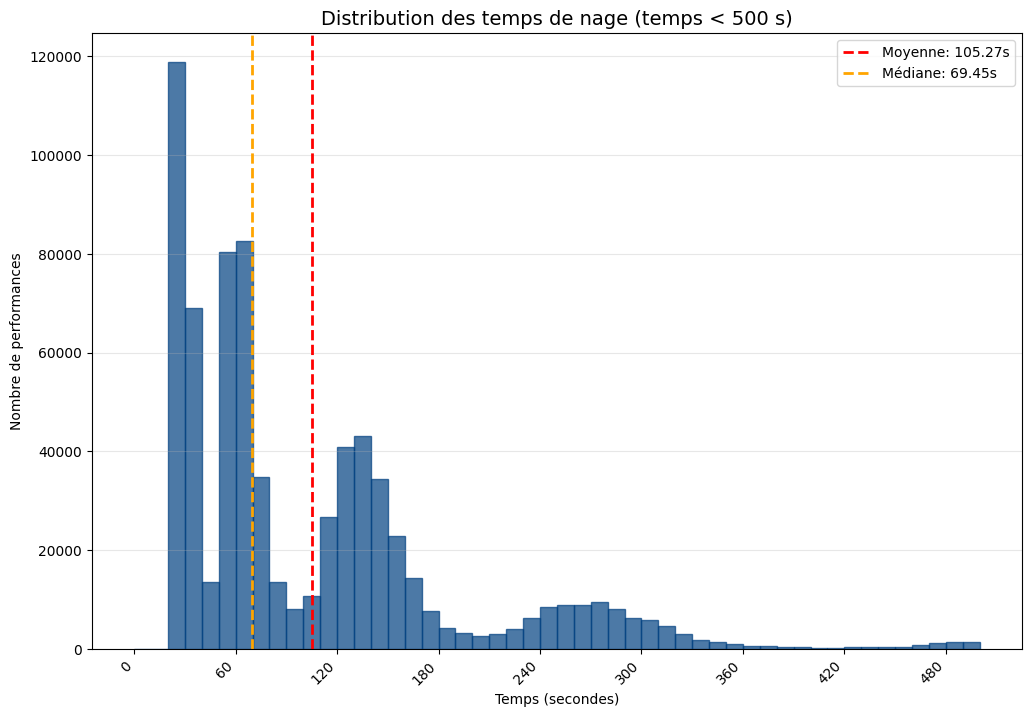

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

swim_times = df["SwimTimeSeconds"]
swim_times = swim_times[swim_times < 500]

fig, ax = plt.subplots(figsize=(12,8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2, label=f'Médiane: {median_time:.2f}s')

ax.set_title("Distribution des temps de nage (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))  
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")  

plt.show()

# Histogram with Kernel Density Estimate (KDE)

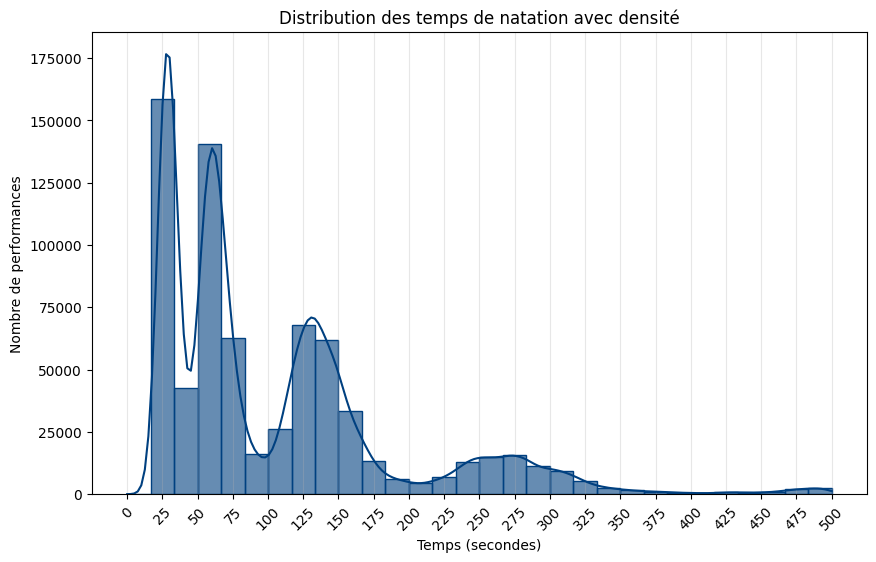

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

swim_times = df["SwimTimeSeconds"].dropna()
swim_times = swim_times[swim_times < 500]

plt.figure(figsize=(10,6))

sns.histplot(swim_times, bins=30, kde=True,
             color="#004080", edgecolor="#004080", alpha=0.6)

plt.title("Distribution des temps de natation avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

# Boxplot

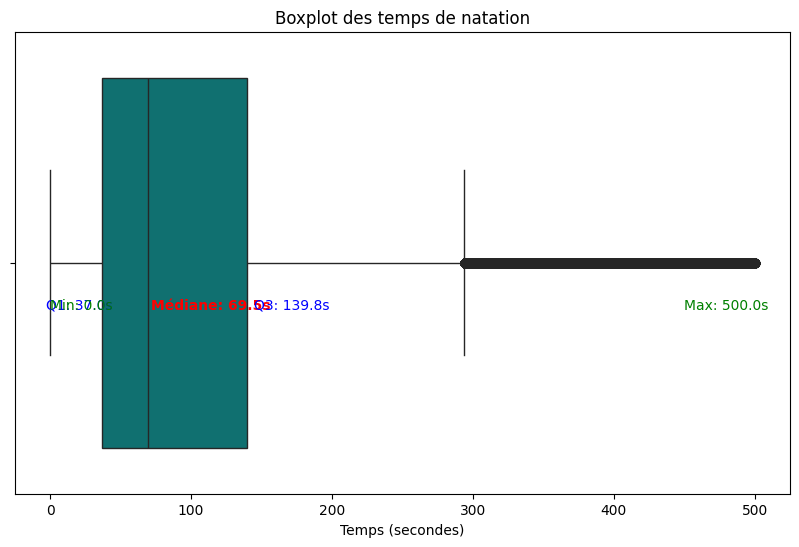

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

swim_times = df["SwimTimeSeconds"].dropna()
swim_times = swim_times[swim_times < 500]

plt.figure(figsize=(10,6))
sns.boxplot(x=swim_times, color="#008080")

median = np.median(swim_times)
q1 = np.percentile(swim_times, 25)
q3 = np.percentile(swim_times, 75)
min_val = swim_times.min()
max_val = swim_times.max()

plt.text(median + 2, 0.1, f"Médiane: {median:.1f}s", color="red", fontsize=10, weight="bold")
plt.text(q1 - 40, 0.1, f"Q1: {q1:.1f}s", color="blue", fontsize=10)
plt.text(q3 + 5, 0.1, f"Q3: {q3:.1f}s", color="blue", fontsize=10)
plt.text(min_val, 0.1, f"Min: {min_val:.1f}s", color="green", fontsize=10)
plt.text(max_val - 50, 0.1, f"Max: {max_val:.1f}s", color="green", fontsize=10)

plt.title("Boxplot des temps de natation")
plt.xlabel("Temps (secondes)")
plt.show()

# Cumulative Histogram

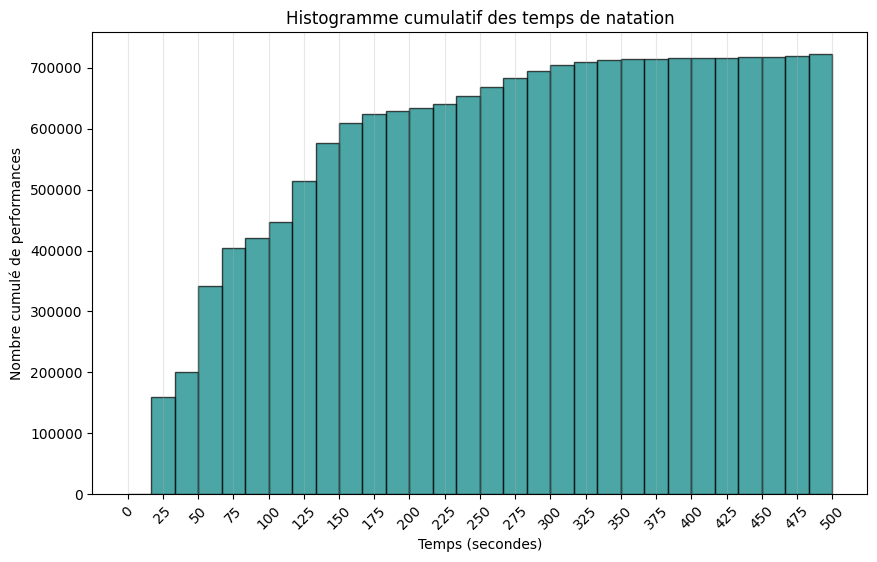

In [19]:
import matplotlib.pyplot as plt
import numpy as np

swim_times = df["SwimTimeSeconds"].dropna()
swim_times = swim_times[swim_times < 500]

plt.figure(figsize=(10,6))

plt.hist(swim_times, bins=30, cumulative=True, color="#008080",
         edgecolor="black", alpha=0.7)

plt.title("Histogramme cumulatif des temps de natation")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre cumulé de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)  

plt.grid(axis="x", alpha=0.3)
plt.show()

# Countplot number of performances by sex

Gender
M    399828
F    362543
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_10014/3315299978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=palette_colors)


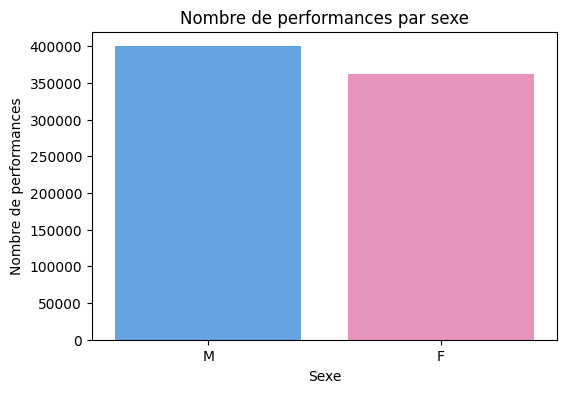

In [19]:
df["Gender"] = df["swimmer"].apply(lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None)

print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

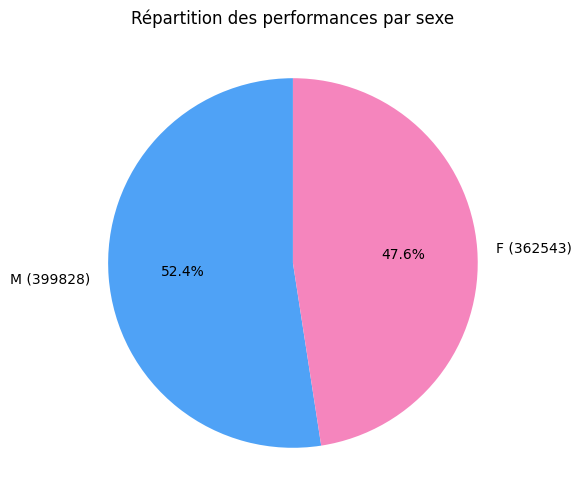

In [22]:
gender_counts = df["Gender"].value_counts()

colors = ["#4FA2F6","#F585BD"]

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Répartition des performances par sexe")

plt.show()

In [21]:
print(df['Stroke'].unique()) # ['FR', 'BK', 'BR', 'FL', 'MD']

['FR' 'BK' 'BR' 'FL' 'MD']


# Barplot of average time per swimming stroke and distance

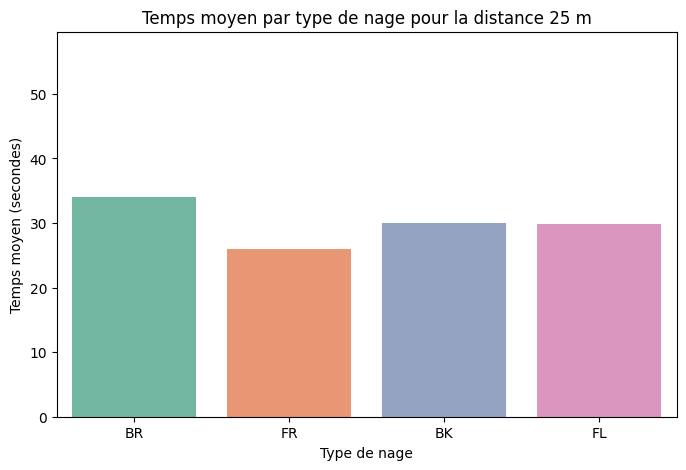

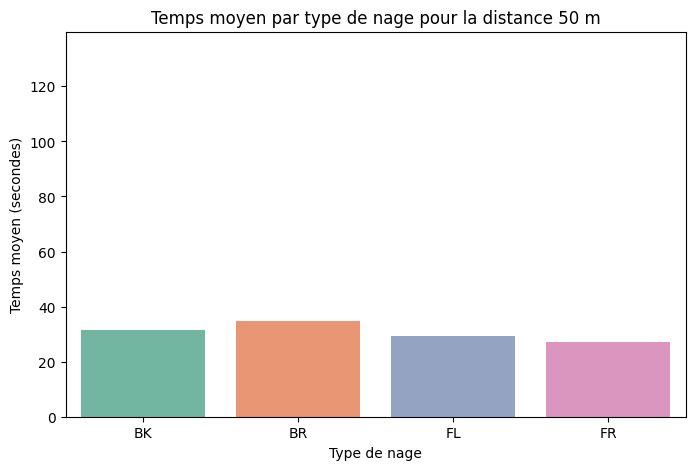

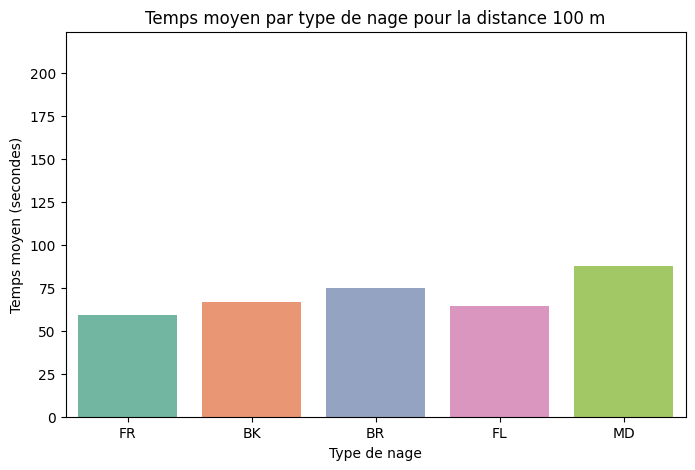

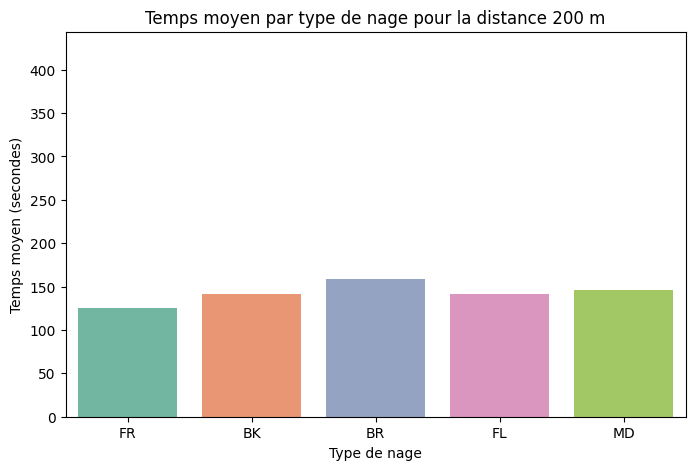

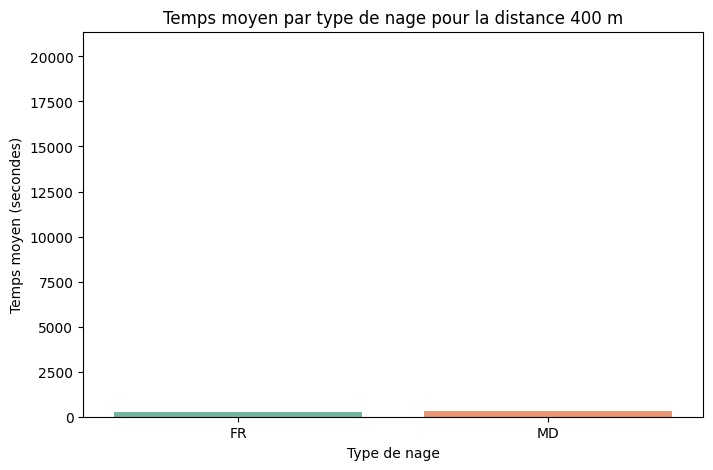

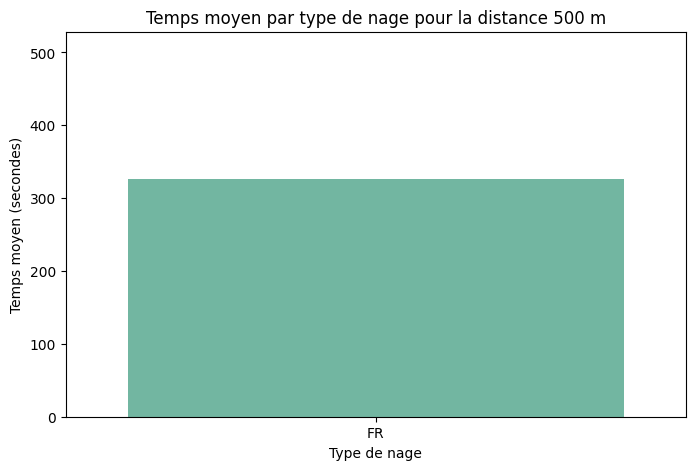

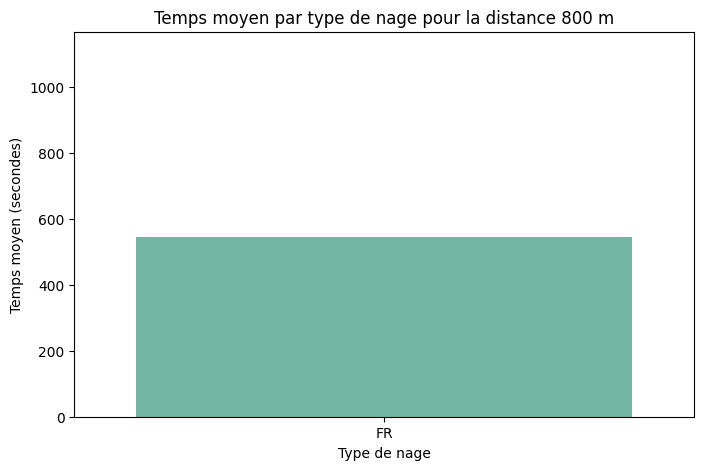

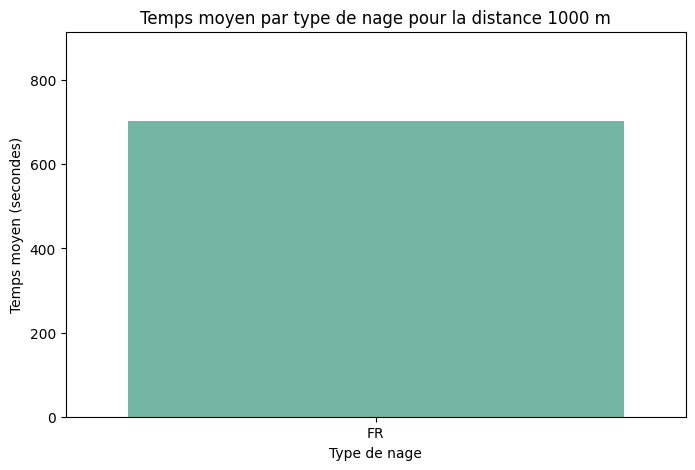

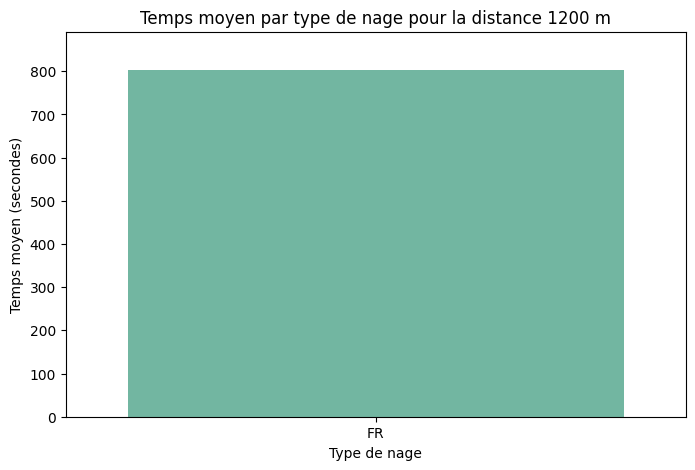

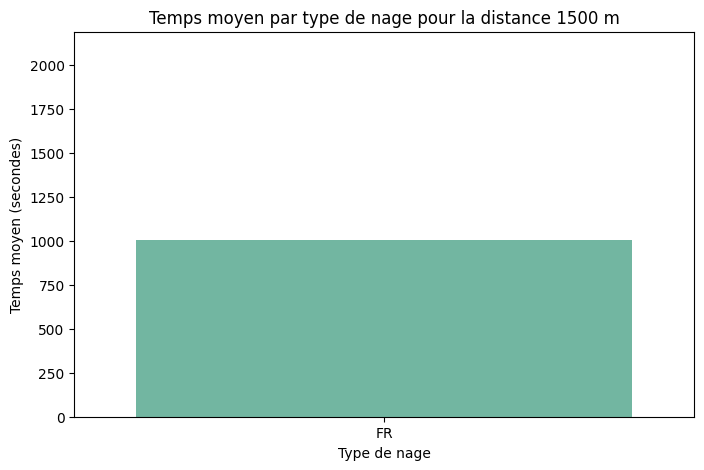

In [22]:
df_times = df[df['SwimTimeSeconds'].notna()]
distances = sorted(df_times['Distance'].unique())

for distance in distances:
    subset = df_times[df_times['Distance'] == distance]
    
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Stroke',
        y='SwimTimeSeconds',
        data=subset,
        hue='Stroke',    
        palette="Set2",
        errorbar=None,
        dodge=False      
    )
    
    plt.title(f"Temps moyen par type de nage pour la distance {distance} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps moyen (secondes)")
    plt.ylim(0, subset['SwimTimeSeconds'].max() + 5)  
    plt.show()

# Bar Chart: Number of Performances per Club

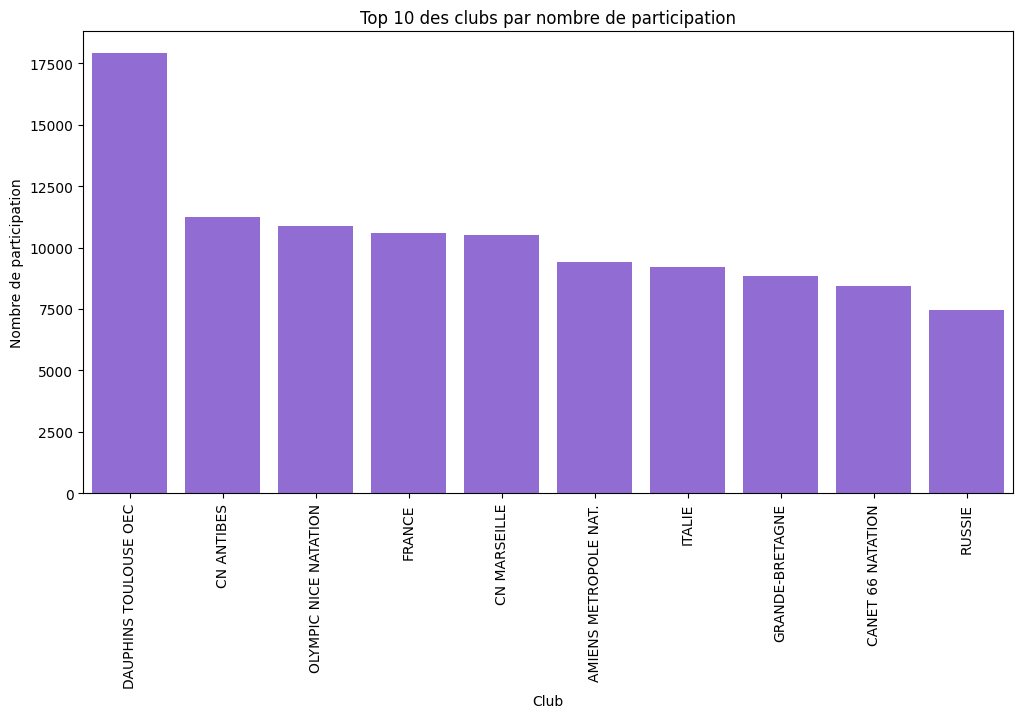

In [23]:
top_clubs = df['Club'].value_counts().nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#8C5CE4")  
plt.title("Top 10 des clubs par nombre de participation")
plt.xlabel("Club")
plt.ylabel("Nombre de participation")
plt.xticks(rotation=90)
plt.show()

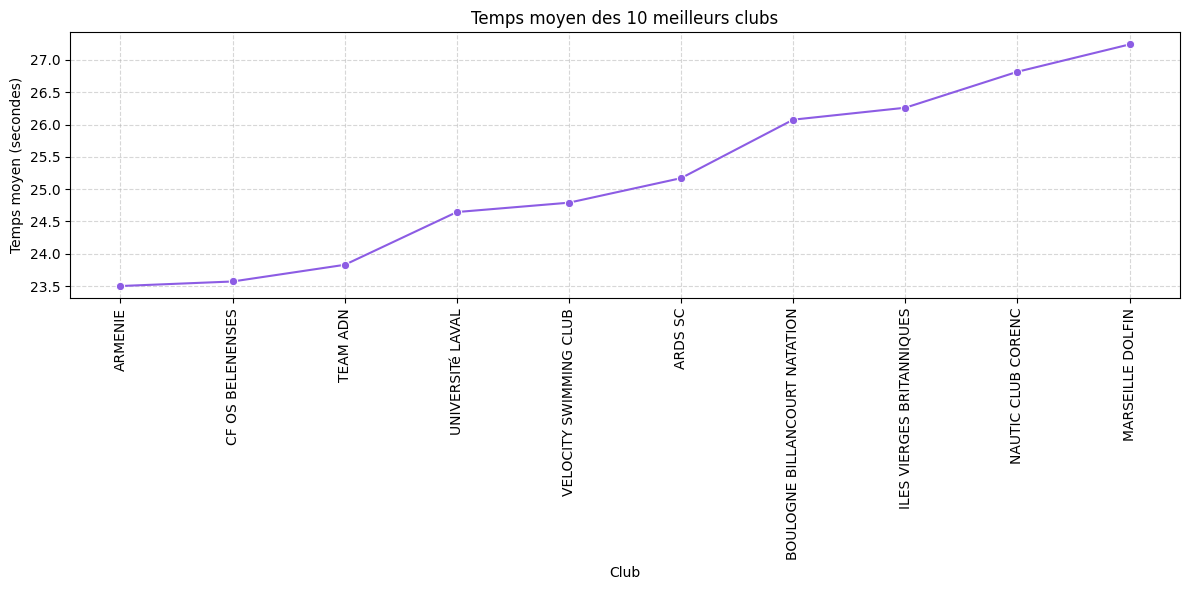

In [24]:
df_time = df[df['SwimTimeSeconds'].notna()]

mean_time_club = df_time.groupby('Club')['SwimTimeSeconds'].mean().reset_index()

mean_time_club = mean_time_club.sort_values('SwimTimeSeconds')

top10_clubs = mean_time_club.head(10)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=top10_clubs,
    x='Club',
    y='SwimTimeSeconds',
    marker='o',
    color="#8C5CE4"
)

plt.title("Temps moyen des 10 meilleurs clubs")
plt.xlabel("Club")
plt.ylabel("Temps moyen (secondes)")
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Boxplot by Stroke Type

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/3875048533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SwimTimeSeconds', y='Stroke', data=df, palette="Set2")


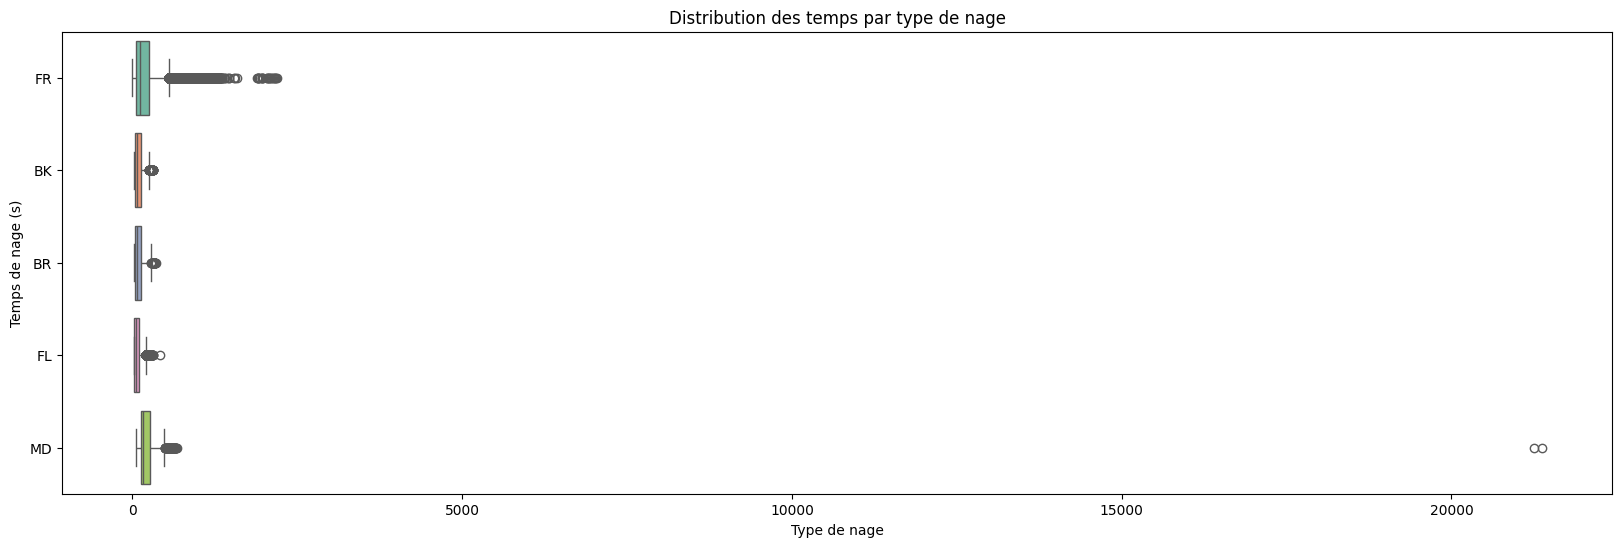

In [25]:
plt.figure(figsize=(20,6))
sns.boxplot(x='SwimTimeSeconds', y='Stroke', data=df, palette="Set2")
plt.title("Distribution des temps par type de nage")
plt.xlabel("Type de nage")
plt.ylabel("Temps de nage (s)")
plt.show()

# Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000

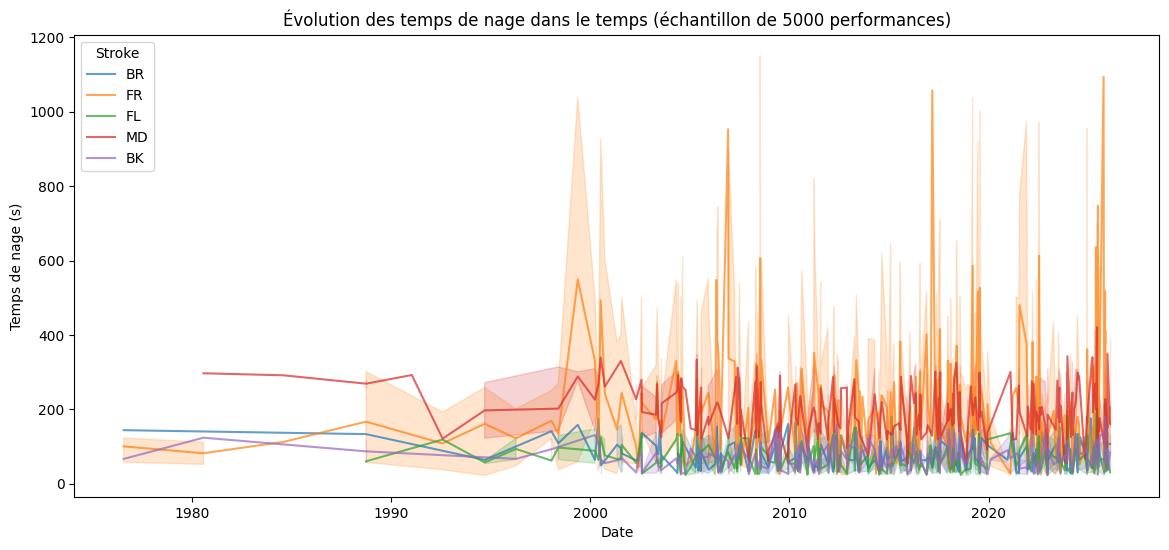

In [26]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'])
plt.figure(figsize=(14,6))
sns.lineplot(x='SwimDate', y='SwimTimeSeconds', data=df.sample(5000), hue='Stroke', alpha=0.7)
plt.title("Évolution des temps de nage dans le temps (échantillon de 5000 performances)")
plt.xlabel("Date")
plt.ylabel("Temps de nage (s)")
plt.legend(title='Stroke')
plt.show()

# Heatmap of Average Swim Times by Distance and Stroke Type

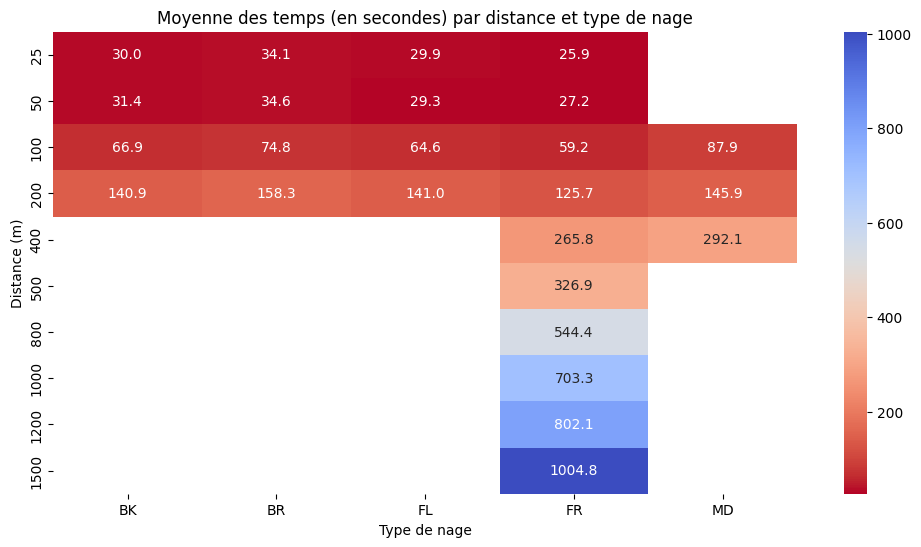

In [27]:
pivot = df.pivot_table(values='SwimTimeSeconds', index='Distance', columns='Stroke', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm_r")
plt.title("Moyenne des temps (en secondes) par distance et type de nage")
plt.xlabel("Type de nage")
plt.ylabel("Distance (m)")
plt.show()

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


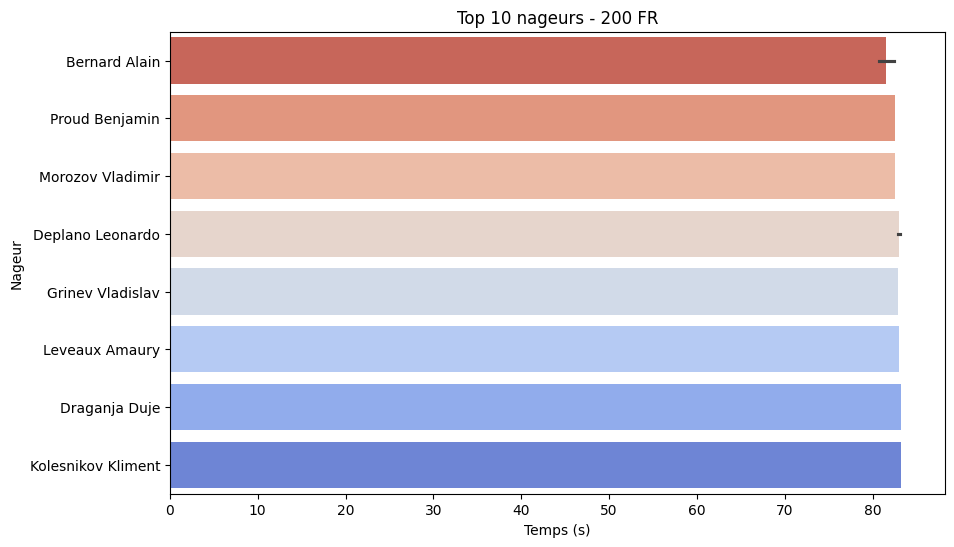

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


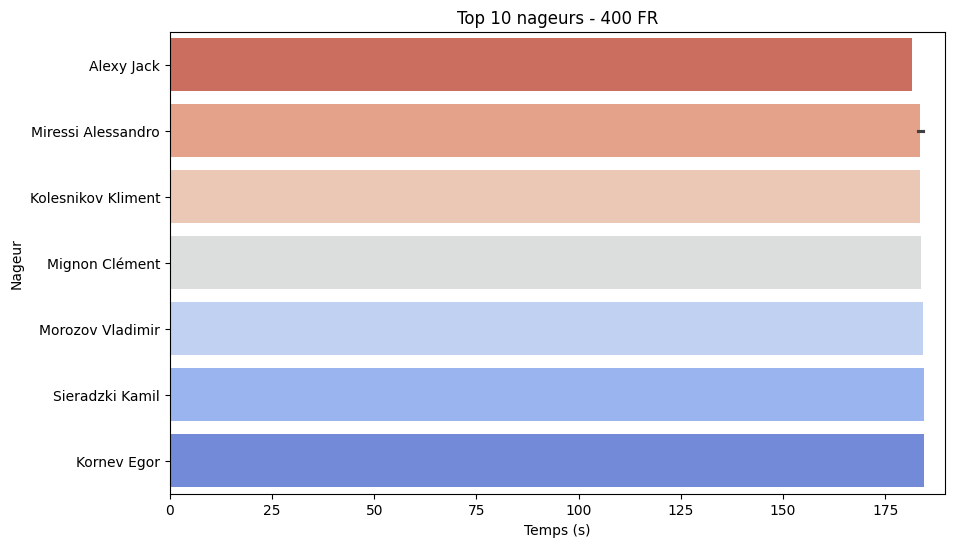

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


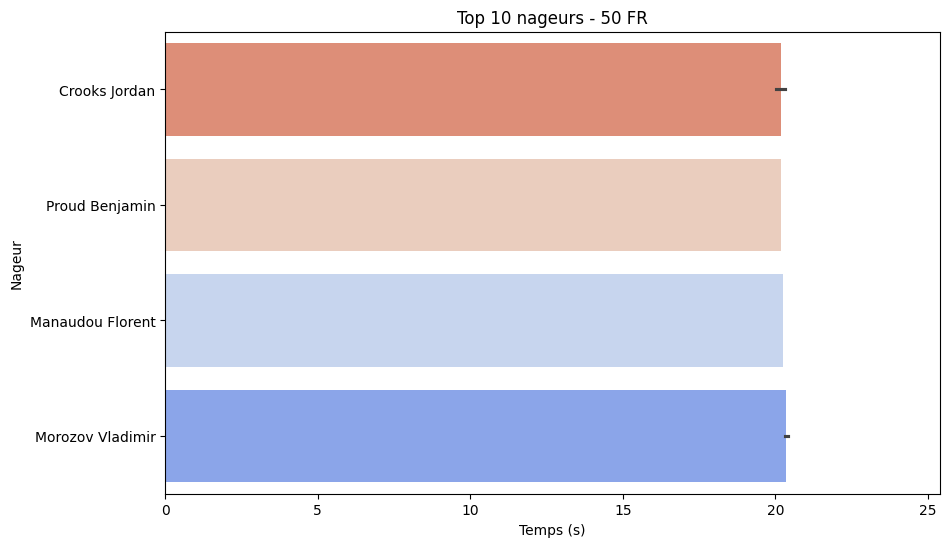

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


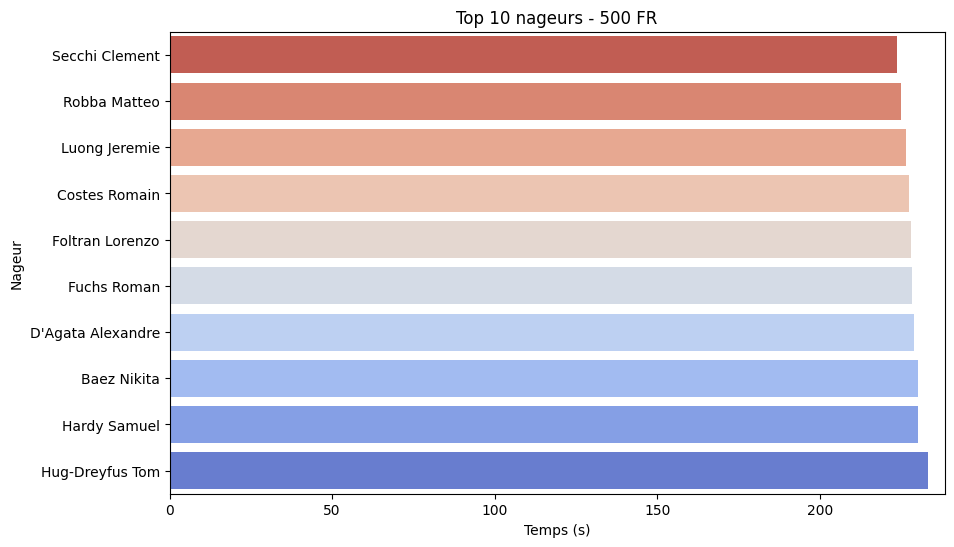

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


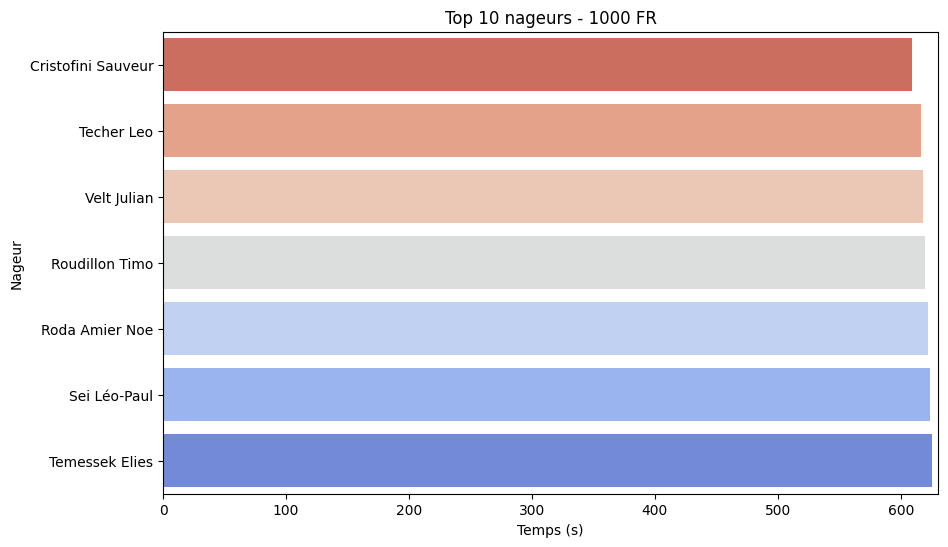

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


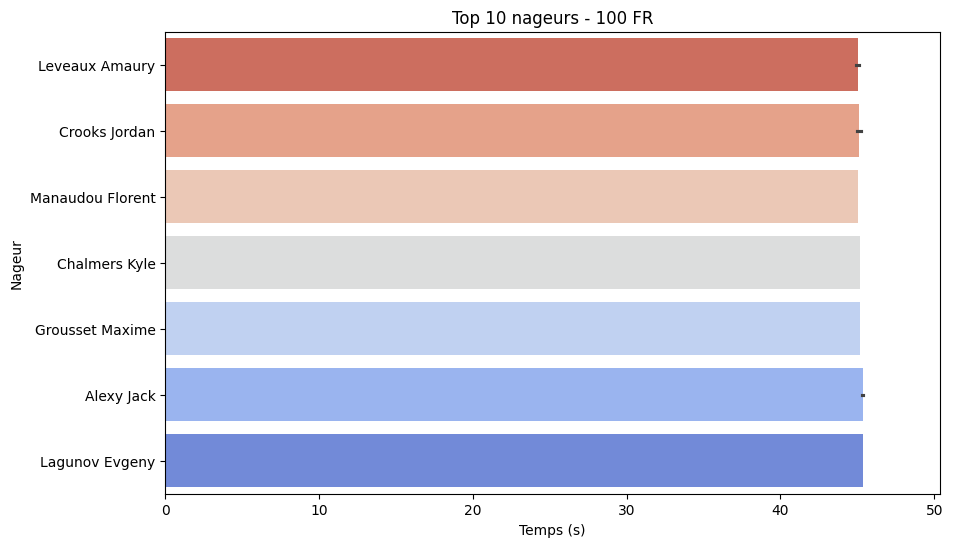

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


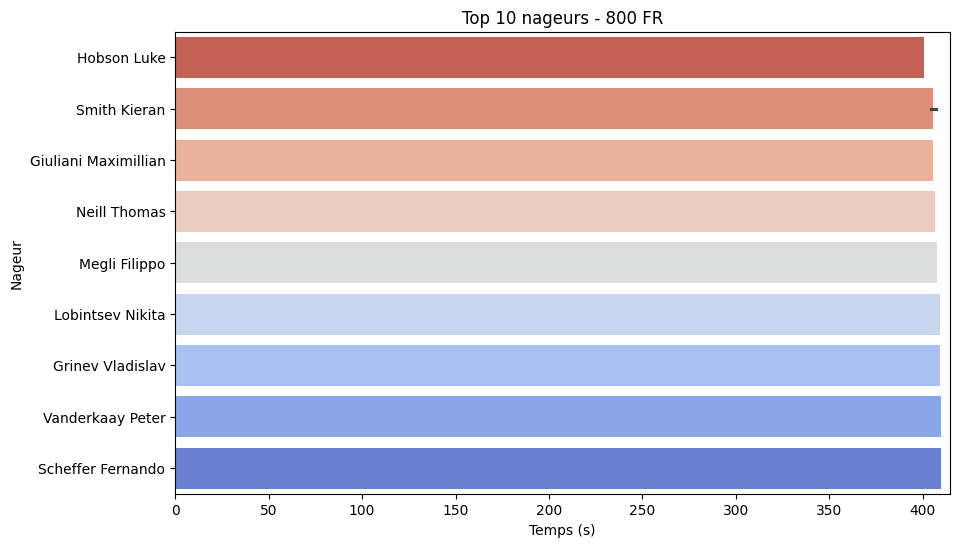

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


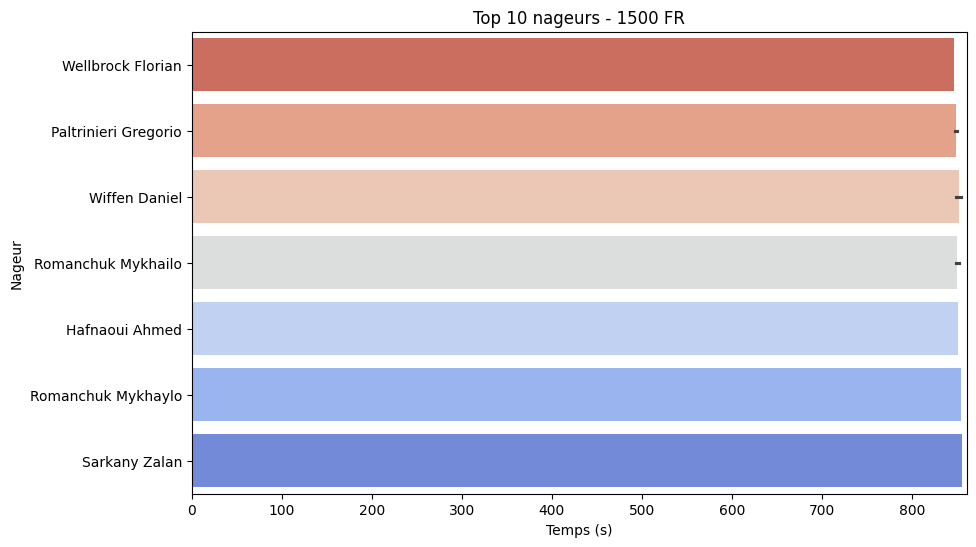

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


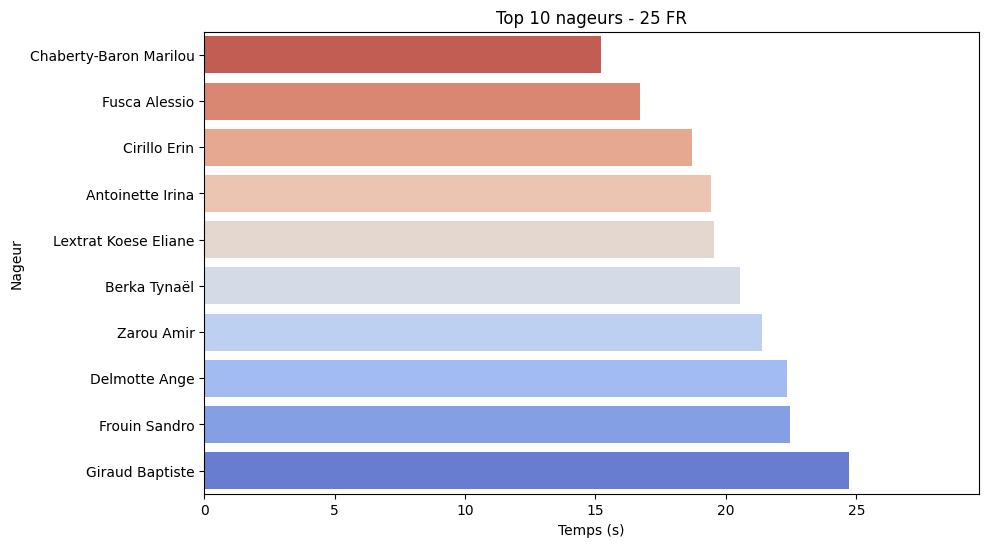

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


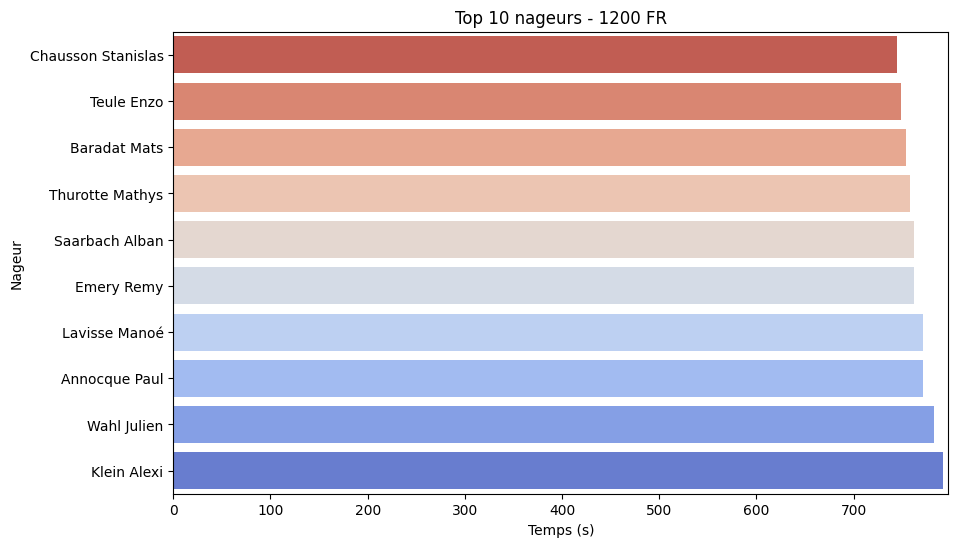

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


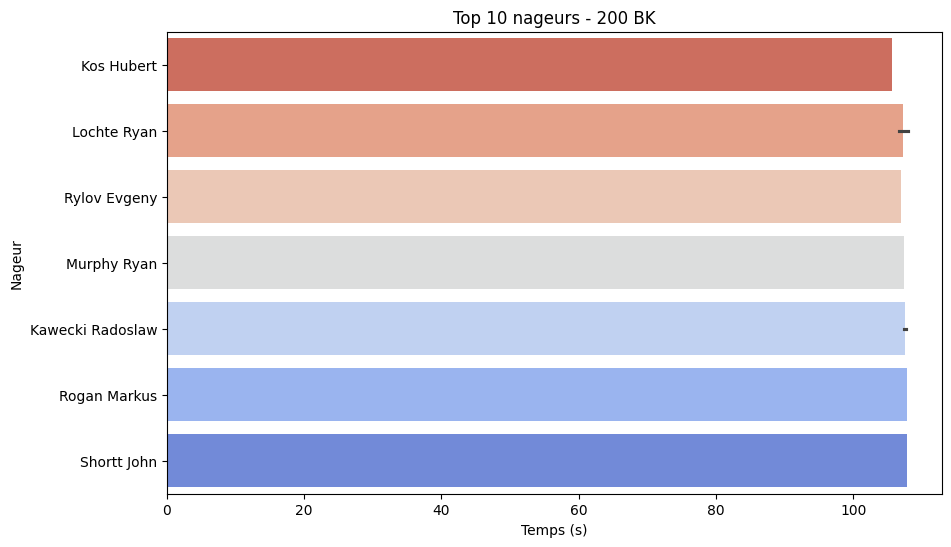

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


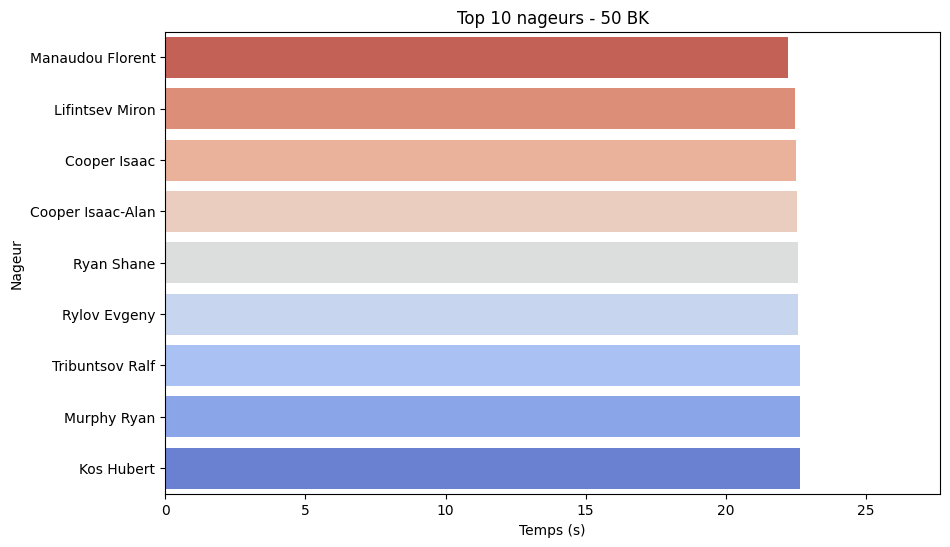

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


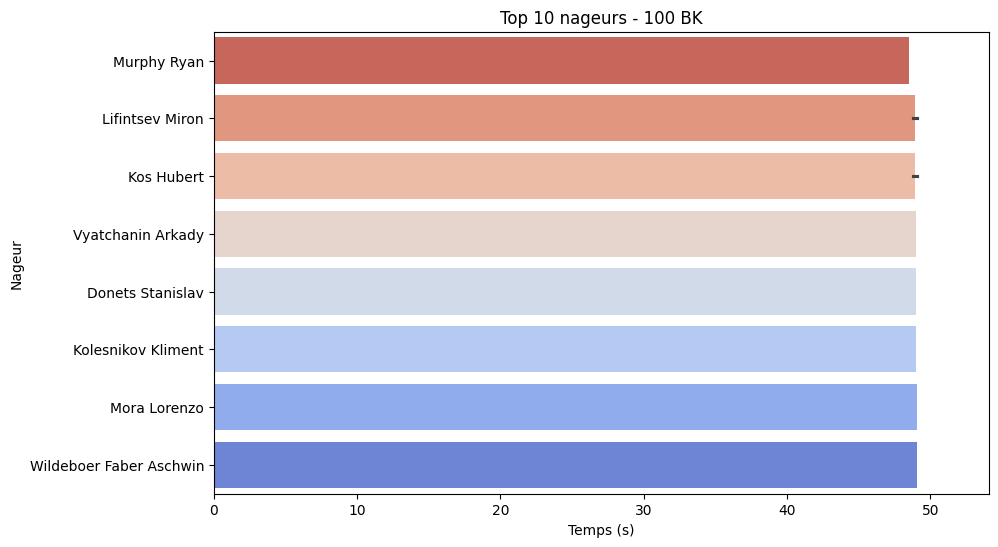

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


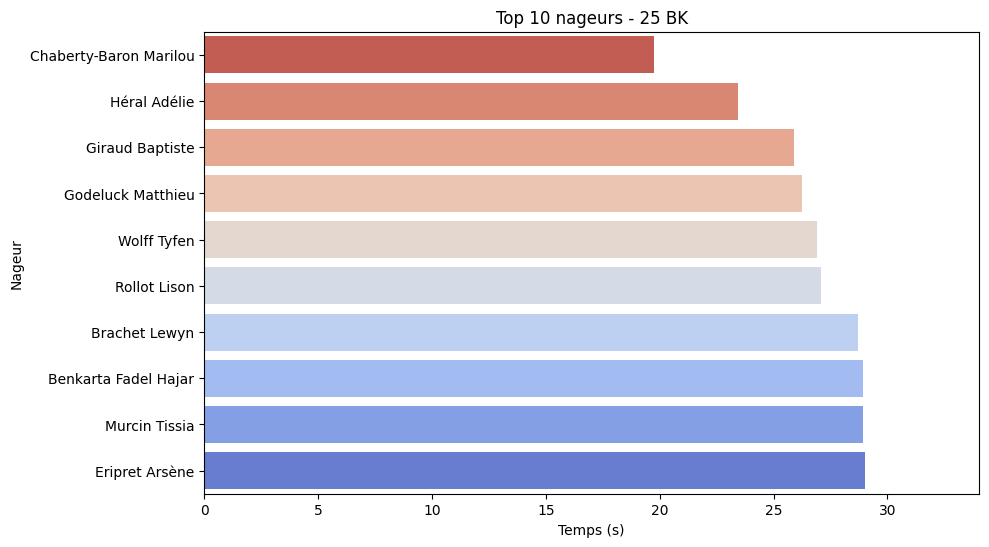

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


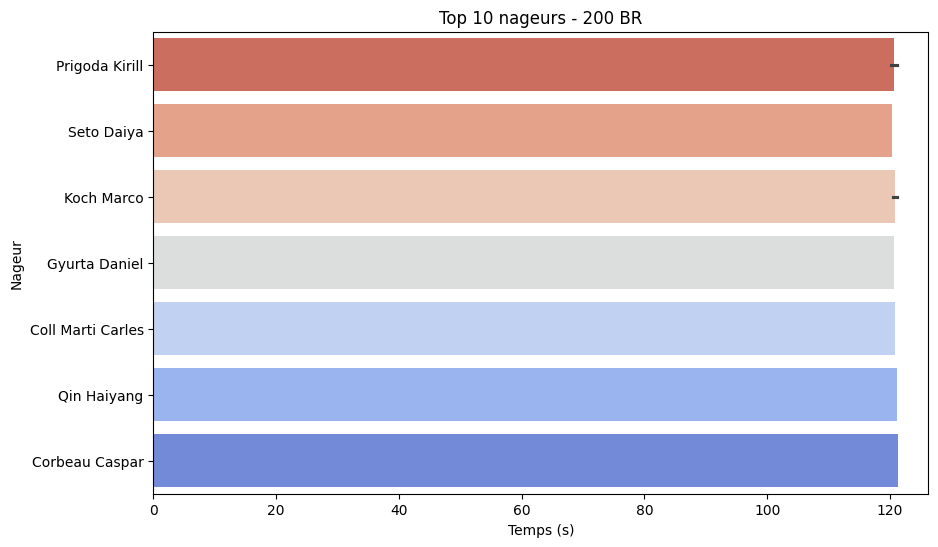

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


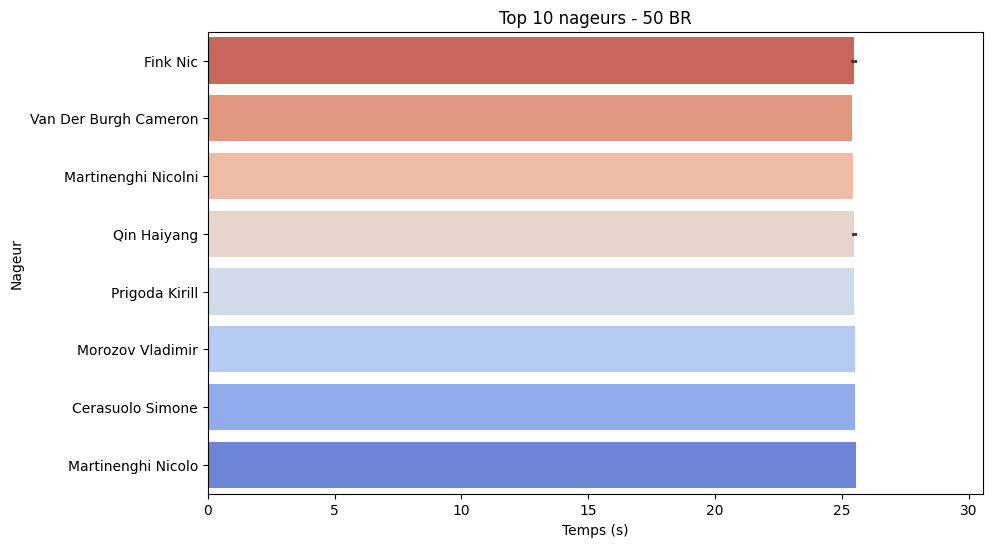

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


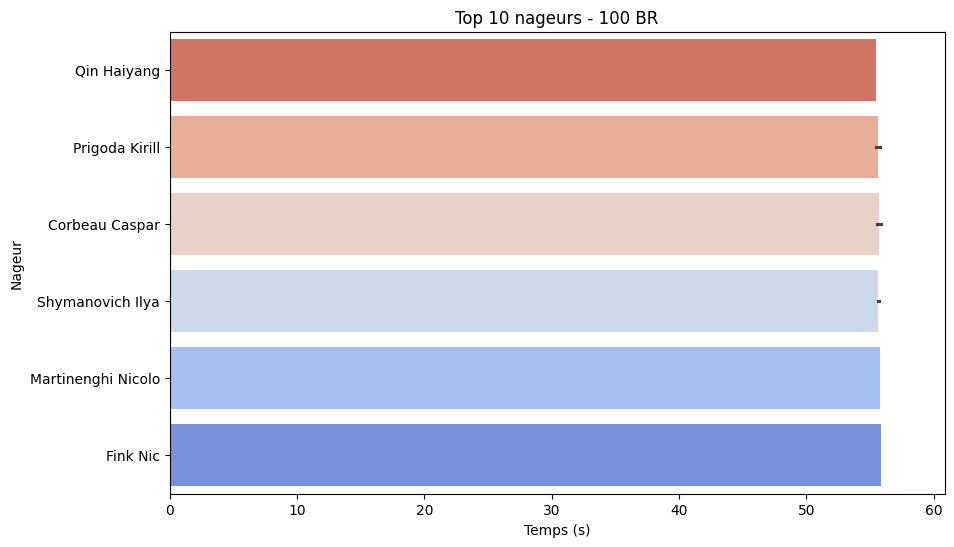

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


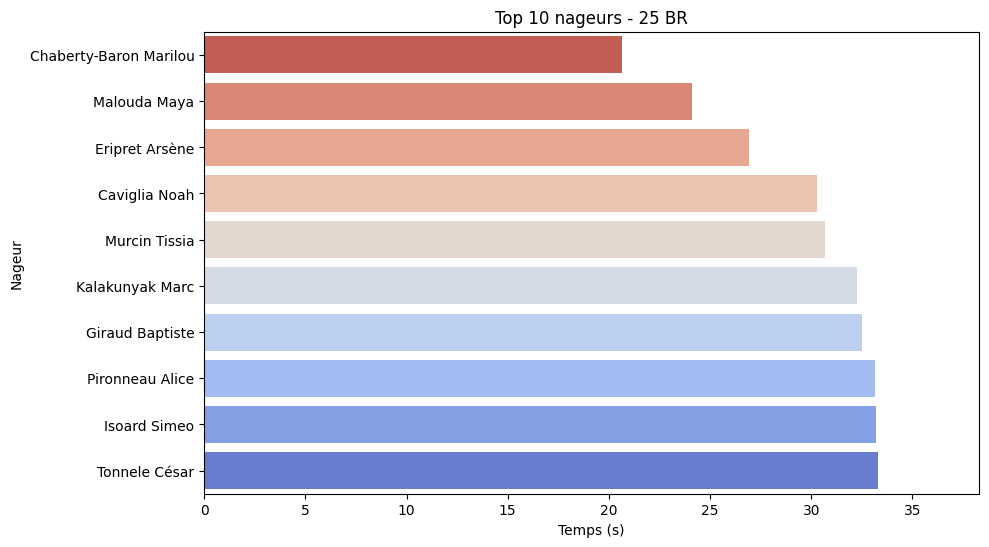

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


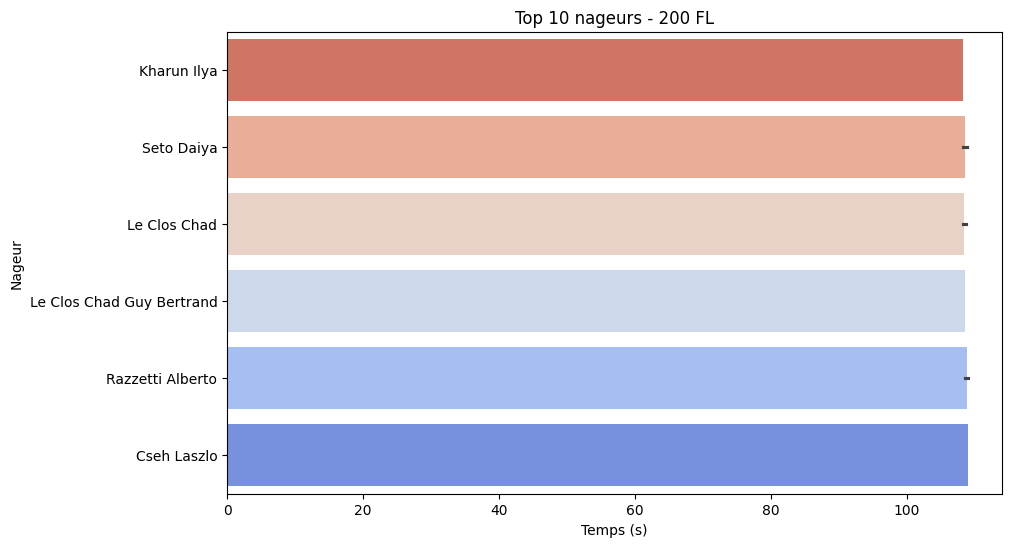

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


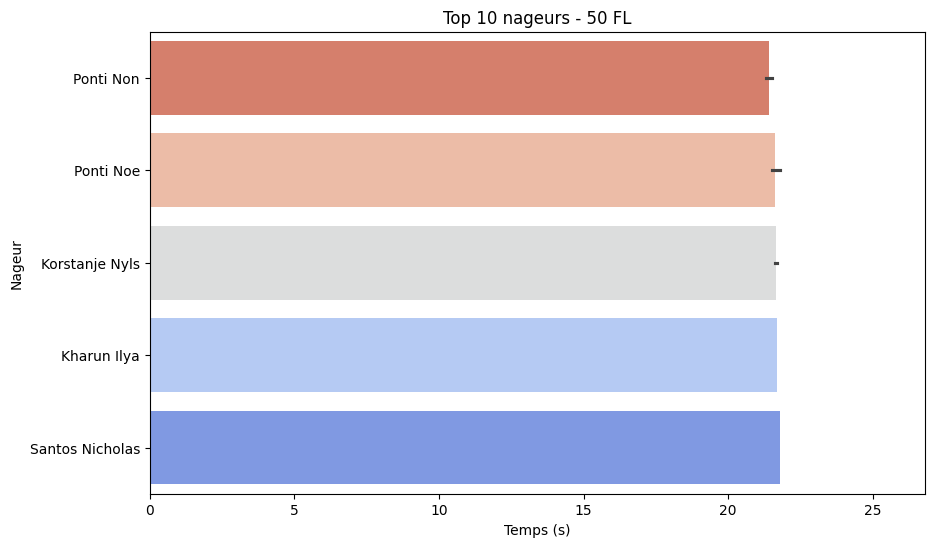

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


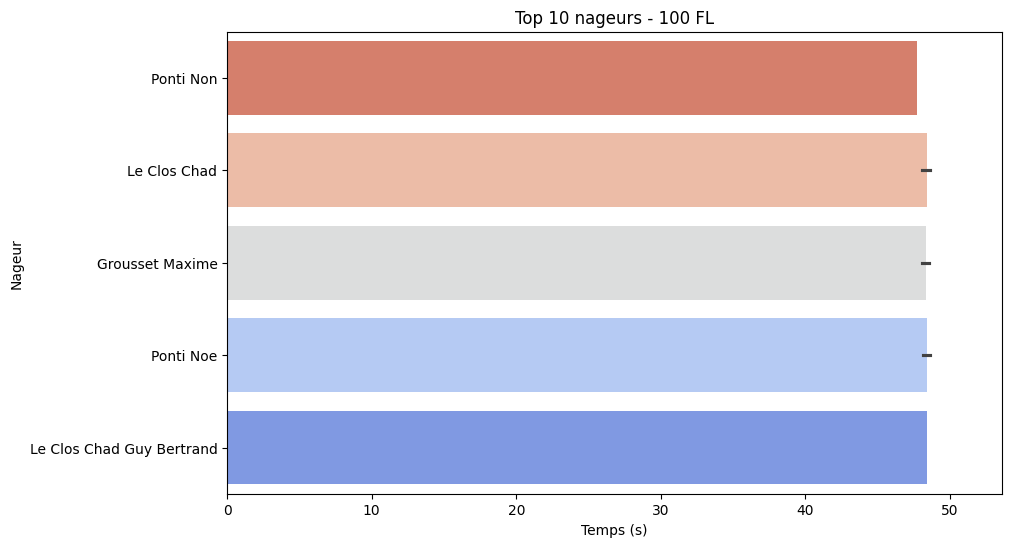

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


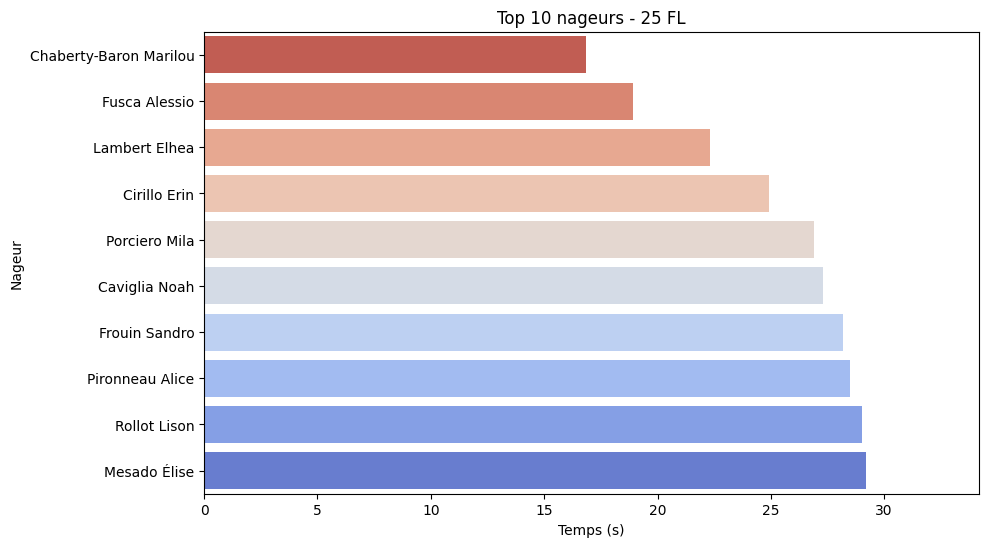

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


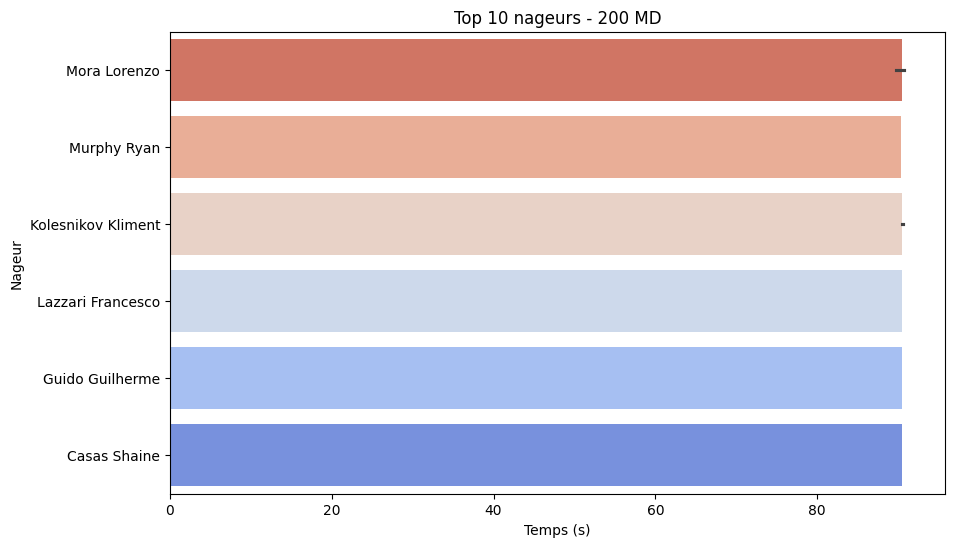

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


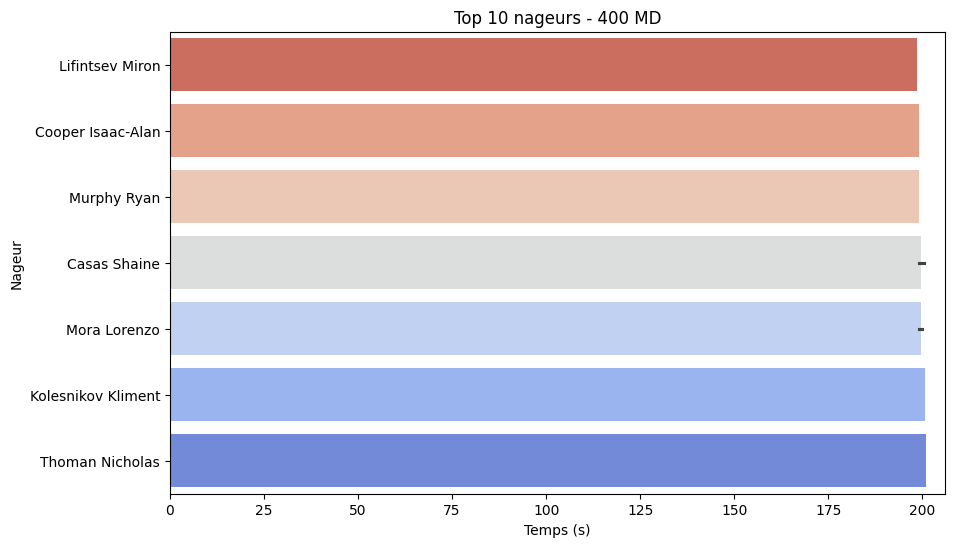

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2481/6119150.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


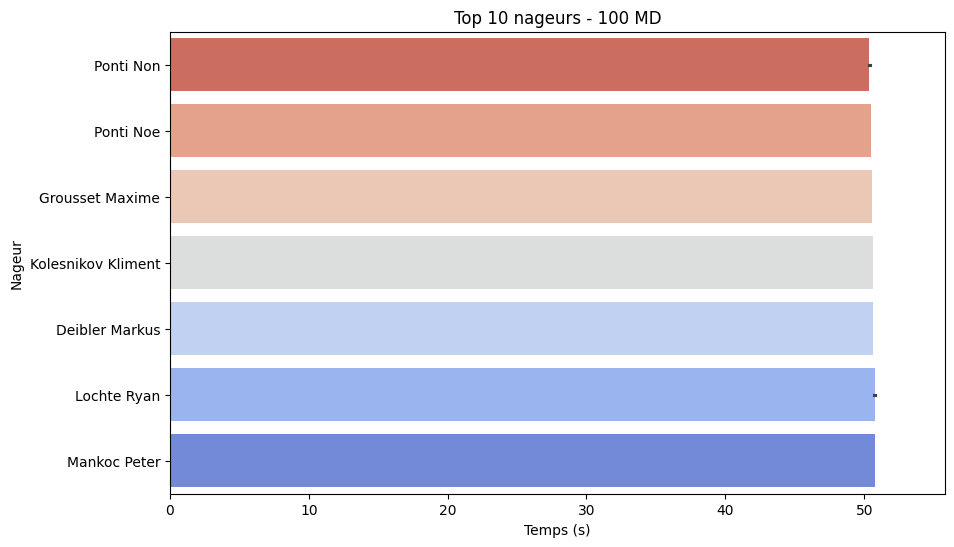

In [28]:
df_clean = df[df['SwimTimeSeconds'].notna() & (df['SwimTimeSeconds'] > 0)]

strokes = df_clean['Stroke'].unique()
distances = df_clean['Distance'].unique()

for stroke in strokes:
    for distance in distances:
        subset = df_clean[(df_clean['Stroke'] == stroke) & 
                          (df_clean['Distance'] == distance) & 
                          (df_clean['SwimTimeSeconds'] > 0)]
        if subset.empty:
            continue
        
        subset['SwimmerName'] = subset['swimmer'].apply(lambda x: x[0]['Name'] if x else "Unknown")
        
        top10 = subset.nsmallest(10, 'SwimTimeSeconds')
        
        plt.figure(figsize=(10,6))
        sns.barplot(
            x='SwimTimeSeconds', 
            y='SwimmerName', 
            data=top10, 
            palette="coolwarm_r", 
            orient='h'
        )
        plt.title(f"Top 10 nageurs - {distance} {stroke}")
        plt.xlabel("Temps (s)")
        plt.ylabel("Nageur")
        plt.xlim(0, top10['SwimTimeSeconds'].max() + 5)
        plt.show()

In [29]:
print(df["Distance"].sort_values(ascending=True).unique()) # [  25   50  100  200  400  500  800 1000 1200 1500]

[  25   50  100  200  400  500  800 1000 1200 1500]


# Lineplot of Speed Performance Across Distances by Stroke

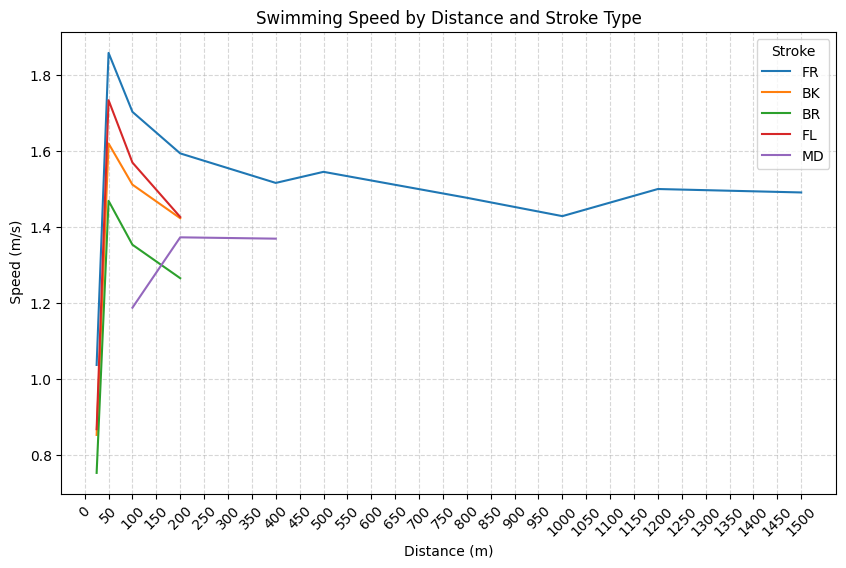

'\nDécroissance rapide de la vitesse \nOn voit que pour toutes les nages, la vitesse chute fortement après 50 m, ce qui est normal physiologiquement (sprint initial vs endurance).\n'

In [30]:
df_speed = df[df['Speed'].notna()]

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=df_speed,
    errorbar=None
)

max_distance = int(df_speed['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50), rotation=45)

plt.title("Swimming Speed by Distance and Stroke Type")
plt.xlabel("Distance (m)")
plt.ylabel(" Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
"""
Décroissance rapide de la vitesse 
On voit que pour toutes les nages, la vitesse chute fortement après 50 m, ce qui est normal physiologiquement (sprint initial vs endurance).
"""


Top 10 swimmers for stroke: BK


,Swimmer,SwimTimeSeconds,Distance
681084,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",19.75,25
222264,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",22.22,50
35461,"{'Name': 'Lifintsev Miron', 'Gender': 'M', 'Ye...",22.47,50
35462,"{'Name': 'Cooper Isaac', 'Gender': 'M', 'Year_...",22.49,50
24529,"{'Name': 'Cooper Isaac-Alan', 'Gender': 'M', '...",22.52,50
...,...,...,...
658357,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",137.88,200
747788,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",160.39,200
412943,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,50
315795,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100



Top 10 swimmers for stroke: BR


,Swimmer,SwimTimeSeconds,Distance
681108,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",20.66,25
308429,"{'Name': 'Malouda Maya', 'Gender': 'F', 'Year_...",24.12,25
24680,"{'Name': 'Fink Nic', 'Gender': 'M', 'Year_of_b...",25.38,50
65169,"{'Name': 'Van Der Burgh Cameron', 'Gender': 'M...",25.41,50
35661,"{'Name': 'Qin Haiyang', 'Gender': 'M', 'Year_o...",25.42,50
...,...,...,...
88928,"{'Name': 'Qin Haiyang', 'Gender': 'M', 'Year_o...",133.35,200
187194,"{'Name': 'Shymanovich Ilya', 'Gender': 'M', 'Y...",133.46,200
90817,"{'Name': 'Shymanovich Ilya', 'Gender': 'M', 'Y...",133.85,200
34090,"{'Name': 'Van Der Burgh Cameron', 'Gender': 'M...",135.10,200



Top 10 swimmers for stroke: FL


,Swimmer,SwimTimeSeconds,Distance
681128,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",16.85,25
681029,"{'Name': 'Fusca Alessio', 'Gender': 'M', 'Year...",18.91,25
35901,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.32,50
35909,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",21.43,50
18266,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",21.51,50
...,...,...,...
28990,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",122.19,200
171566,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",124.19,200
171590,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",124.65,200
433103,"{'Name': 'Grousset Maxime', 'Gender': 'M', 'Ye...",NaN,50



Top 10 swimmers for stroke: FR


,Swimmer,SwimTimeSeconds,Distance
182140,"{'Name': 'Hindley Isabella', 'Gender': 'F', 'Y...",0.00,100
664830,"{'Name': 'Penet Anatole', 'Gender': 'M', 'Year...",0.00,50
681059,"{'Name': 'Chaberty-Baron Marilou', 'Gender': '...",15.23,25
680966,"{'Name': 'Fusca Alessio', 'Gender': 'M', 'Year...",16.70,25
681060,"{'Name': 'Cirillo Erin', 'Gender': 'F', 'Year_...",18.71,25
...,...,...,...
452474,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100
515662,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100
557989,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100
607404,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",NaN,100



Top 10 swimmers for stroke: MD


,Swimmer,SwimTimeSeconds,Distance
36149,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",50.33,100
36157,"{'Name': 'Ponti Non', 'Gender': 'M', 'Year_of_...",50.43,100
18471,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",50.52,100
18472,"{'Name': 'Grousset Maxime', 'Gender': 'M', 'Ye...",50.53,100
656328,"{'Name': 'Grousset Maxime', 'Gender': 'M', 'Ye...",50.56,100
...,...,...,...
140611,"{'Name': 'Lochte Ryan', 'Gender': 'M', 'Year_o...",257.26,400
605595,"{'Name': 'Manaudou Florent', 'Gender': 'M', 'Y...",259.35,400
179328,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",262.93,400
179341,"{'Name': 'Ponti Noe', 'Gender': 'M', 'Year_of_...",265.42,400


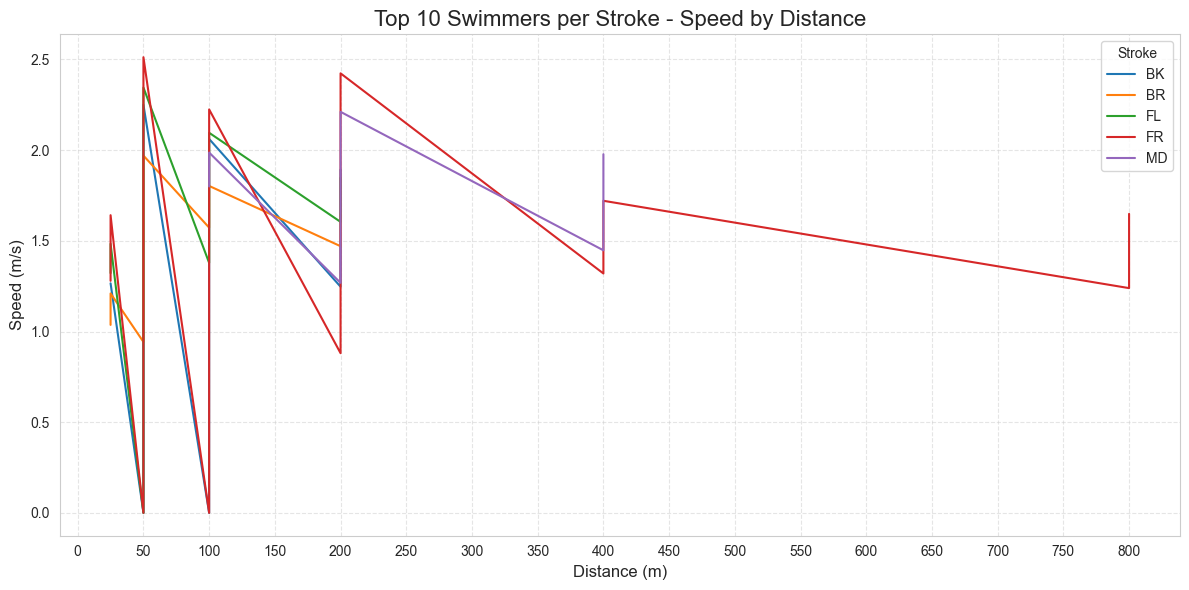

In [ ]:
import mplcursors

df_clean = df[df['Speed'].notna()]

def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name', str(x))
    elif isinstance(x, list) and len(x) > 0:
        return str(x[0])
    else:
        return str(x)
df_clean['Swimmer'] = df_clean['swimmer'].apply(clean_swimmer)

df_clean = df_clean.sort_values(by=['Stroke', 'Swimmer', 'Distance'])

top_swimmers = pd.DataFrame()
for stroke in df_clean['Stroke'].unique():
    df_s = df_clean[df_clean['Stroke'] == stroke].sort_values('SwimTimeSeconds')
    top10 = df_s['Swimmer'].drop_duplicates().head(10)
    top_swimmers = pd.concat([top_swimmers, df_s[df_s['Swimmer'].isin(top10)]])

# Afficher les top nageurs par stroke
for stroke in top_swimmers['Stroke'].unique():
    print(f"\nTop 10 swimmers for stroke: {stroke}")
    display(top_swimmers[top_swimmers['Stroke'] == stroke][['Swimmer','SwimTimeSeconds','Distance']])

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=top_swimmers,
    markers=True,
    dashes=False,
    estimator=None
)

max_distance = int(top_swimmers['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50))  # pas de 50 m

points = list(zip(top_swimmers['Distance'], top_swimmers['Speed'], top_swimmers['Swimmer']))
cursor = mplcursors.cursor(ax.lines, hover=True)

@cursor.connect("add")
def on_add(sel):
    x_data, y_data = sel.target
    nearest = min(points, key=lambda p: (p[0]-x_data)**2 + (p[1]-y_data)**2)
    sel.annotation.set_text(f"{nearest[2]}\nSpeed: {nearest[1]:.2f} m/s\nDistance: {nearest[0]} m")

plt.title("Top 10 Swimmers per Stroke - Speed by Distance", fontsize=16)
plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Speed (m/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Heatmap of Average Swim Speed by Distance and Stroke

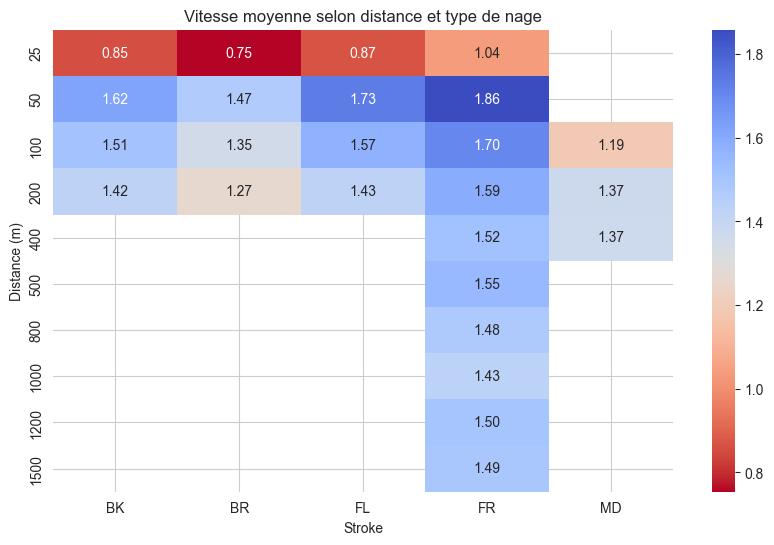

In [32]:
pivot = df.pivot_table(
    values='Speed',
    index='Distance',
    columns='Stroke',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm_r",
    fmt=".2f"
)

plt.title("Vitesse moyenne selon distance et type de nage")
plt.xlabel("Stroke")
plt.ylabel("Distance (m)")

plt.show()

# Lineplot of Speed ​​per split for a precise Swimmer and Event

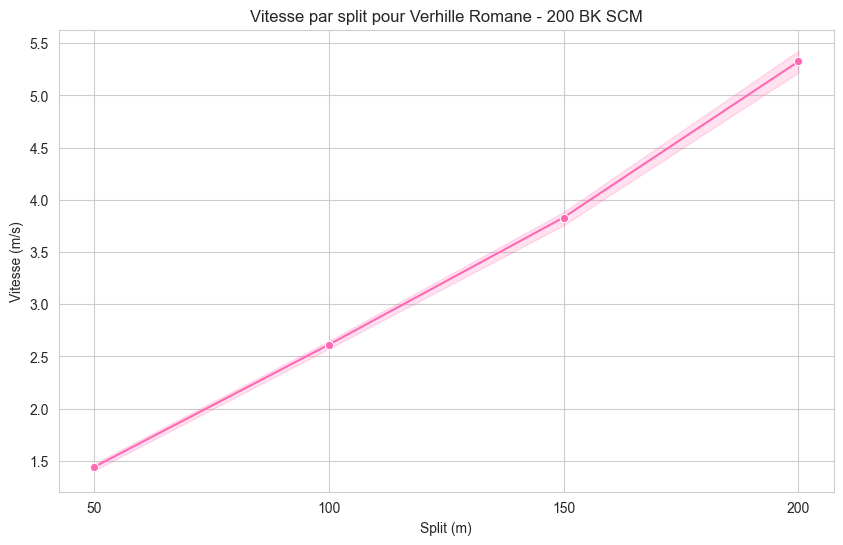

In [33]:
nom_nageur = "Verhille Romane"
nom_event = "200 BK SCM"

split_data = []
gender_nageur = None  

for idx, row in df.iterrows():
    # Vérifier que la ligne correspond à l'Event et contient exactement 1 nageur
    if row['Event'] == nom_event and len(row['swimmer']) == 1:
        swimmer = row['swimmer'][0]
        if swimmer['Name'] == nom_nageur:
            gender_nageur = swimmer['Gender']  
            for s in row['splits']:
                if s['split_speed'] is not None:
                    dist = int(s['split_distance'].replace(' m',''))
                    split_data.append({
                        'split_distance': dist,
                        'split_speed': s['split_speed']
                    })

df_splits = pd.DataFrame(split_data)

df_splits = df_splits.sort_values('split_distance')

if gender_nageur == "M":
    color_line = "#003E80"  
elif gender_nageur == "F":
    color_line = "#FF69B4"  
else:
    color_line = "#008080"  

plt.figure(figsize=(10,6))
sns.lineplot(
    x='split_distance',
    y='split_speed',
    data=df_splits,
    marker='o',
    color=color_line
)
plt.xticks(range(50, df_splits['split_distance'].max()+50, 50)) 
plt.title(f"Vitesse par split pour {nom_nageur} - {nom_event}")
plt.xlabel("Split (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.show()

# Lineplot of split speed for the best swimmers for a specific event

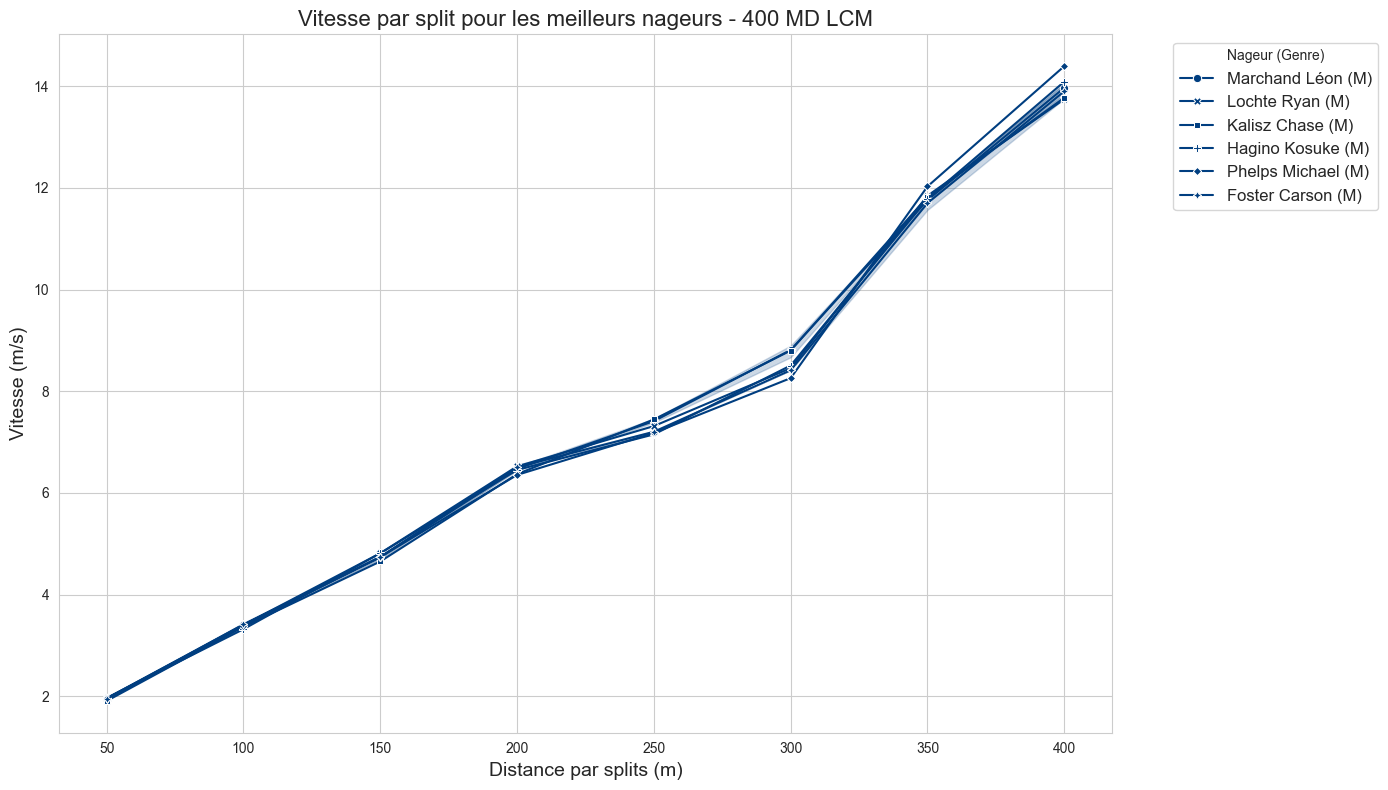

In [34]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top10 = df_event.nsmallest(top_n, 'SwimTimeSeconds')

split_data = []
for idx, row in df_top10.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits: 
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top 10 nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

# Lineplot of split speed for the best swimmers for a specific event (women vs men)

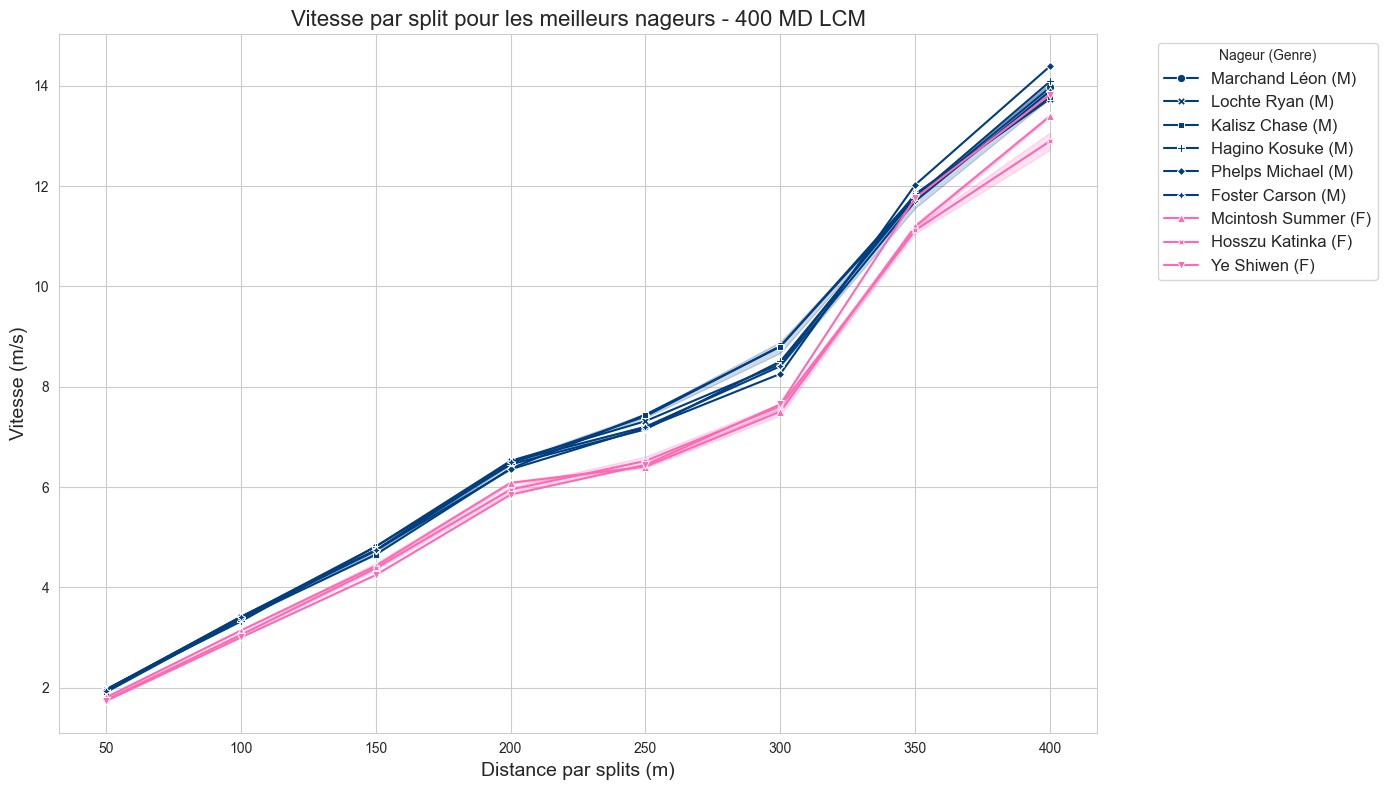

In [35]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')

df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    swimmer_name = row['swimmer_name']
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits: 
        for s in splits:
            if s['split_speed'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'swimmer': swimmer_name,
                    'gender': gender,
                    'split_distance': dist,
                    'split_speed': s['split_speed']
                })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucun split valide trouvé pour les top nageurs.")
else:
    df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

    palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

    palette_for_plot = {label: palette_colors[gender] for label, gender in zip(df_splits['swimmer_label'], df_splits['gender'])}

    plt.figure(figsize=(14,8))
    sns.lineplot(
        x='split_distance',
        y='split_speed',
        hue='swimmer_label',
        style='swimmer_label',
        data=df_splits,
        markers=True,
        dashes=False,
        palette=palette_for_plot
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour les meilleurs nageurs - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

# Lineplot of split speed for the best swimmer in a given event

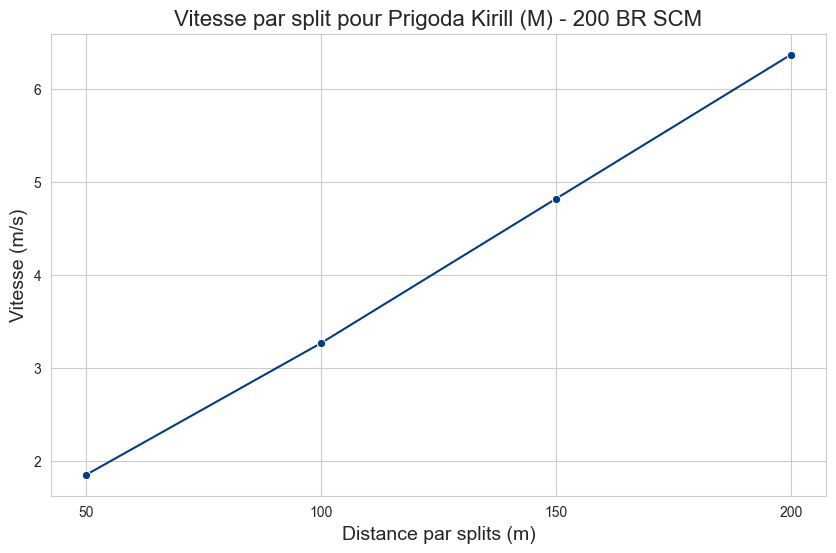

In [36]:
nom_event = "200 BR SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]

best_name = df_best['swimmer_name']
best_gender = df_best['swimmer_gender']
best_splits = df_best['splits']

split_data = []
for s in best_splits:
    if s['split_speed'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_data.append({
            'split_distance': dist,
            'split_speed': s['split_speed']
        })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print(f"Aucun split valide trouvé pour le meilleur nageur de l'Event {nom_event}.")
else:
    plt.figure(figsize=(10,6))
    color = "#003E80" if best_gender == 'M' else "#FF69B4"

    sns.lineplot(
        x='split_distance',
        y='split_speed',
        data=df_splits,
        marker='o',
        color=color
    )

    plt.xticks(range(50, df_splits['split_distance'].max()+50, 50))
    plt.title(f"Vitesse par split pour {best_name} ({best_gender}) - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse (m/s)", fontsize=14)
    plt.grid(True)
    plt.show()

# Lineplot of average of swim time by splits

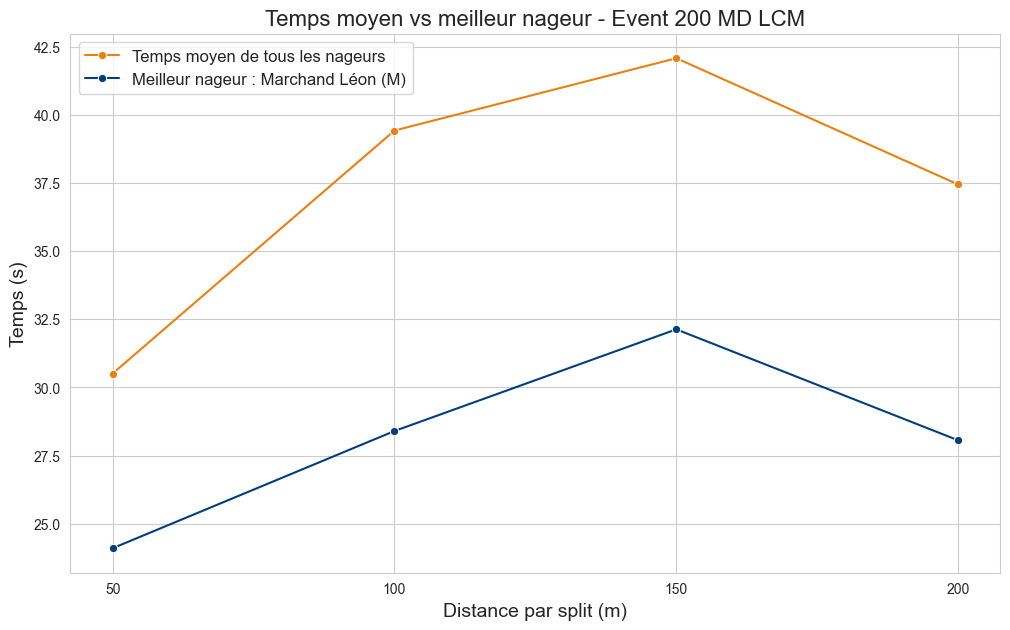

In [37]:
nom_event = "200 MD LCM"  
df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]
best_name = df_best['swimmer'][0]['Name']
best_gender = df_best['swimmer'][0]['Gender']
best_splits = df_best['splits']

split_best_data = []
for s in best_splits:
    if s['split_seconds'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_best_data.append({
            'split_distance': dist,
            'split_seconds': s['split_seconds']
        })

df_best_splits = pd.DataFrame(split_best_data)

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

color_best = "#003E80" if best_gender == 'M' else "#FF69B4"
sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_best_splits,
    marker='o',
    color=color_best,
    label=f"Meilleur nageur : {best_name} ({best_gender})"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(), df_best_splits['split_distance'].max())+50, 50))
plt.title(f"Temps moyen vs meilleur nageur - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

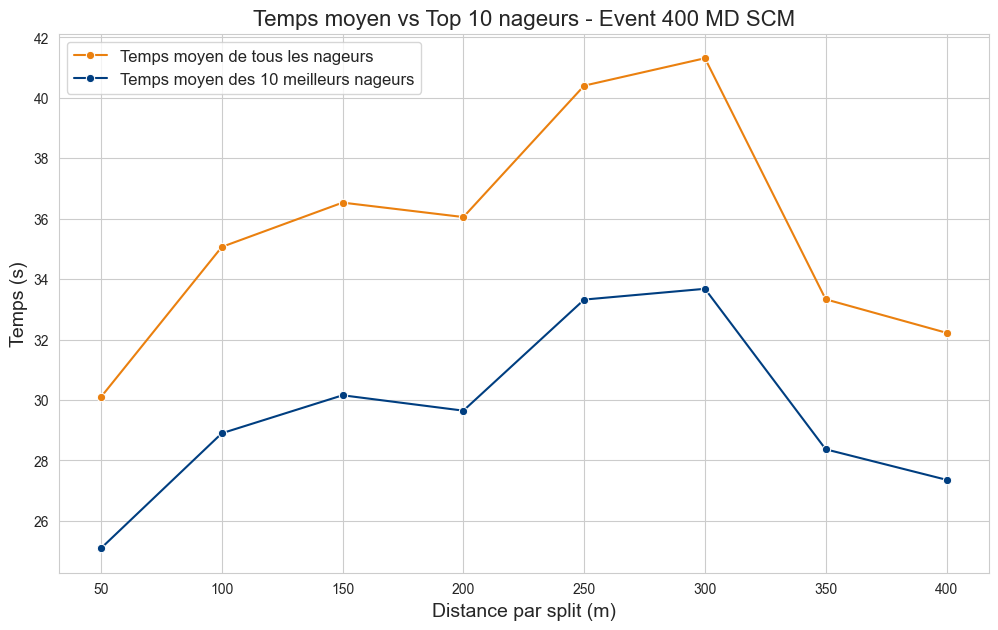

In [38]:
nom_event = "400 MD SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_mean_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

df_top10 = df_event.nsmallest(10, 'SwimTimeSeconds')

top10_split_data = []

for idx, row in df_top10.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                top10_split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_top10_splits = pd.DataFrame(top10_split_data)

df_top10_mean = df_top10_splits.groupby('split_distance', as_index=False)['split_seconds'].mean()

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_mean_splits,
    marker='o',
    color="#EA800F",
    label="Temps moyen de tous les nageurs"
)

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_top10_mean,
    marker='o',
    color="#003E80",
    label="Temps moyen des 10 meilleurs nageurs"
)

plt.xticks(range(50, max(df_mean_splits['split_distance'].max(),
                         df_top10_mean['split_distance'].max()) + 50, 50))

plt.title(f"Temps moyen vs Top 10 nageurs - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

plt.show()

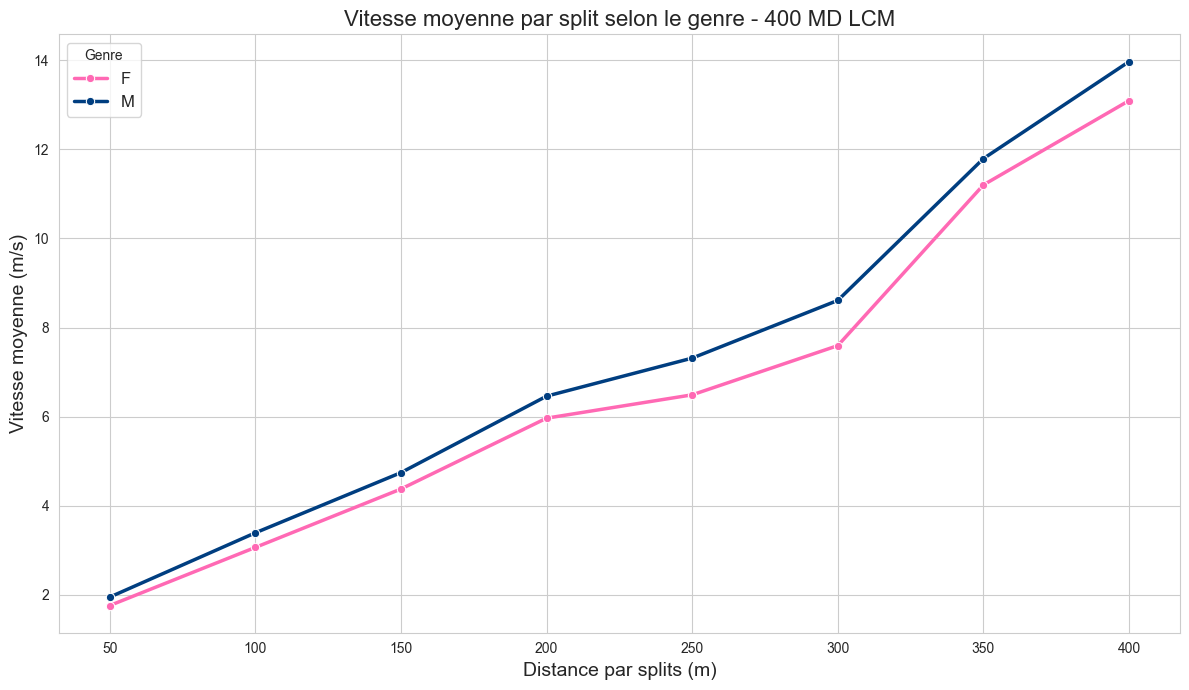

In [39]:
nom_event = "400 MD LCM"  
top_n = 10                

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')
df_top_all = pd.concat([df_top_men, df_top_women])

split_data = []
for idx, row in df_top_all.iterrows():
    gender = row['swimmer_gender']
    splits = row['splits']
    if splits:
        for s in splits:
            dist = int(s['split_distance'].replace(' m',''))
            split_speed = s['split_speed'] if s['split_speed'] is not None else float('nan')
            split_data.append({
                'gender': gender,
                'split_distance': dist,
                'split_speed': split_speed
            })

df_splits = pd.DataFrame(split_data)

df_avg = df_splits.groupby(['gender', 'split_distance'])['split_speed'].mean().reset_index()

plt.figure(figsize=(12,7))
palette_colors = {'M': "#003E80", 'F': "#FF69B4"}

sns.lineplot(
    x='split_distance',
    y='split_speed',
    hue='gender',
    data=df_avg,
    marker='o',
    palette=palette_colors,
    linewidth=2.5
)

plt.xticks(range(50, int(df_splits['split_distance'].max())+50, 50))
plt.title(f"Vitesse moyenne par split selon le genre - {nom_event}", fontsize=16)
plt.xlabel("Distance par splits (m)", fontsize=14)
plt.ylabel("Vitesse moyenne (m/s)", fontsize=14)
plt.grid(True)
plt.legend(title='Genre', fontsize=12)
plt.tight_layout()
plt.show()

In [40]:
print(df["Event"].unique())

['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']


In [41]:
# Filtrer les lignes avec des splits valides et un seul nageur (pas une liste de plusieurs nageurs)
df_single_swimmer_splits = df_with_splits[
    df_with_splits["swimmer"].apply(lambda x: isinstance(x, list) and len(x) == 1)
]

# Récupérer le nom du nageur et compter les nageurs uniques
swimmer_names_single = df_single_swimmer_splits["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and x and isinstance(x[0], dict) else None
)

n_unique_swimmers = swimmer_names_single.dropna().nunique()
n_rows = df_single_swimmer_splits.shape[0]

print("Nombre de lignes avec un seul nageur et des splits valides :", n_rows)
print("Nombre de nageurs uniques avec un seul nageur et des splits valides :", n_unique_swimmers)

Nombre de lignes avec un seul nageur et des splits valides : 467538
Nombre de nageurs uniques avec un seul nageur et des splits valides : 53416


In [18]:
nom_event = "200 FR LCM"

df_filtered = df[
    (df['Event'] == nom_event) &
    (df['swimmer'].apply(len) == 1) &
    (df['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0))
]
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print(df_filtered.shape)
print(df_filtered.swimmer)

(35578, 21)
12081                         [{'Name': 'Van Almsick Franziska', 'Gender': 'F', 'Year_of_birth': 1978, 'Nationality': 'GER'}]
12082                                 [{'Name': 'Potec Camelia', 'Gender': 'F', 'Year_of_birth': 1982, 'Nationality': 'ROU'}]
12083                            [{'Name': 'Popchanka Alena V.', 'Gender': 'F', 'Year_of_birth': 1979, 'Nationality': 'BLR'}]
12084                [{'Name': 'Figues De Sainte Marie Solenne', 'Gender': 'F', 'Year_of_birth': 1979, 'Nationality': 'FRA'}]
12085                                    [{'Name': 'Roca Laura', 'Gender': 'F', 'Year_of_birth': 1980, 'Nationality': 'ESP'}]
12086                                 [{'Name': 'Rouba Tatiana', 'Gender': 'F', 'Year_of_birth': 1983, 'Nationality': 'ESP'}]
12087                           [{'Name': 'Hjorth Hansen Julie', 'Gender': 'F', 'Year_of_birth': 1984, 'Nationality': 'DEN'}]
12088                             [{'Name': 'Van Rooijen Manon', 'Gender': 'F', 'Year_of_birth': 1982, 'Na